<a href="https://colab.research.google.com/github/omarbemo/Data_Analysis/blob/main/fifa19_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.FIFA World Cup**

*The FIFA World Cup, often simply called the World Cup, is an international association football competition contested by the senior men's national teams of the members of the Fédération Internationale de Football Association (FIFA), the sport's global governing body. The championship has been awarded every four years since the inaugural tournament in 1930, except in 1942 and 1946 when it was not held because of the Second World War. The current champion is France, which won its second title at the 2018 tournament in Russia*.

![](https://en.wikipedia.org/wiki/FIFA_World_Cup#/media/File:Tour_da_Ta%C3%A7a_da_Copa_do_Mundo_(14231974005).jpg)*The 21 World Cup tournaments have been won by eight national teams. Brazil have won five times, and they are the only team to have played in every tournament. The other World Cup winners are Germany and Italy, with four titles each; Argentina, France, and inaugural winner Uruguay, with two titles each; and England and Spain, with one title each.*

# ***2.Important Libaries***

In [245]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ***3.Read Datasheet***

In [246]:
df=pd.read_csv("fifa_eda.csv")
print(df.shape)

(18207, 18)


*So the dataset has 18 attributes and 18207 rows*

A randome sample to expect a more accurate results

In [247]:
df.sample(10)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
4914,205352,J. Archer,25,Scotland,70,73,Millwall,1600.0,6.0,Right,1.0,1.0,GK,2015,2019-01-01,6.250000,176.0,3100.000000
156,230666,Gabriel Jesus,21,Brazil,83,92,Manchester City,41000.0,130.0,Right,2.0,4.0,ST,2016,2023-01-01,5.750000,161.0,84100.000000
6640,229640,M. Pedersen,21,Denmark,68,77,FC Nordsjælland,1200.0,4.0,Left,1.0,3.0,LWB,2014,2020-01-01,5.833333,163.0,1700.000000
4865,220700,M. Azira,30,Uganda,70,70,Montreal Impact,1300.0,5.0,Right,1.0,3.0,RCM,2018,2018-01-01,5.833333,161.0,2000.000000
11690,239018,Junio,21,Brazil,64,74,Rio Ave FC,625.0,4.0,Right,1.0,2.0,RB,2016,2019-06-30,6.000000,165.0,4585.060806
3531,203368,E. Andersen,25,Norway,72,73,Strømsgodset IF,3700.0,4.0,Right,1.0,3.0,LM,2016,2019-01-01,5.916667,161.0,4900.000000
16406,237659,J. Tabinas,19,Philippines,57,68,Kawasaki Frontale,150.0,1.0,Left,1.0,2.0,LB,2017,2021-01-01,6.000000,170.0,225.000000
12309,242238,O. Solet,18,France,63,83,Olympique Lyonnais,675.0,4.0,Right,1.0,2.0,CB,2018,2022-01-01,6.333333,179.0,2000.000000
2768,159818,Élton,32,Brazil,73,73,Al Qadisiyah,3100.0,18.0,Left,1.0,5.0,RW,2017,2019-01-01,5.166667,132.0,5100.000000
8820,234764,David Haro,27,Spain,66,66,GIF Sundsvall,675.0,2.0,Right,1.0,3.0,LW,2018,2019-01-01,5.500000,134.0,844.000000


# ***3. Time for cleaning the dataset***

*Dataset cleaning is an important set of any EdA as it will help in understanding the patterns well.
We will start by seeing whether the datset has any null values or not.*


In [248]:
df.isna().sum()

,0
ID,0
Name,0
Age,0
Nationality,0
Overall,0
Potential,0
Club,241
Value,252
Wage,0
Preferred Foot,0


*So we see that the attributes such as 'Club','Contract Valid Until','International Reputation','Skill Moves','Value' contains null values.
We will remove the tuples which contain such null values*

In [249]:
df.dropna(inplace=True)

*Let us check that whether we were able to succesfull remove all the tuples which contained null values.*

In [250]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Nationality,0
Overall,0
Potential,0
Club,0
Value,0
Wage,0
Preferred Foot,0


*So now we can rest assured that all the dataset has been completely cleaned off of null values*

Here i see that the ID column isn't important


In [251]:
df.drop("ID",axis=1,inplace=True)

In [252]:
df.sample(5)

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
9979,O. Rojas,36,Mexico,65,65,Lobos BUAP,60.0,2.0,Right,1.0,2.0,RB,2018,2018-01-01,5.666667,148.0,99.0
7022,E. Manu,24,Netherlands,68,71,Akhisar Belediyespor,1100.0,7.0,Right,1.0,3.0,LW,2018,2021-01-01,5.666667,154.0,2400.0
12848,M. Caillard,24,France,63,69,En Avant de Guingamp,375.0,3.0,Right,1.0,1.0,GK,2017,2020-01-01,6.250000,190.0,825.0
14453,P. Smyth,20,Northern Ireland,61,75,Queens Park Rangers,550.0,1.0,Right,1.0,2.0,RM,2017,2019-01-01,5.750000,148.0,1400.0
404,B. Gomis,32,France,81,81,Al Hilal,14000.0,56.0,Right,3.0,4.0,ST,2018,2020-01-01,6.000000,170.0,23800.0


Now i want to deal with the Age coulmn and get some statistics about it but i must deal with outliers first


In [253]:
Q1=df.Age.quantile(0.25)
Q3=df.Age.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Age >= lower_limit) & (df.Age <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

7.0
10.5
38.5
The data before removing the outliers is(17907, 17)
The data after removing the outliers is(17872, 17)


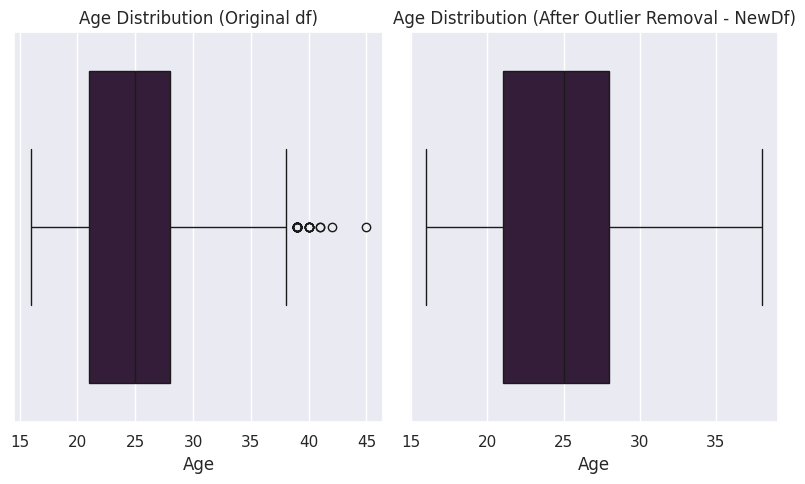

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Age'], ax=axes[0])
axes[0].set_title("Age Distribution (Original df)")

sns.boxplot(x=NewDf['Age'], ax=axes[1])
axes[1].set_title("Age Distribution (After Outlier Removal - NewDf)")

plt.tight_layout()
plt.show()

In [255]:
print('The statistics before adjustment')
print(df[['Age']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Age']].describe())

The statistics before adjustment
                Age
count  17907.000000
mean      25.095605
std        4.660388
min       16.000000
25%       21.000000
50%       25.000000
75%       28.000000
max       45.000000
--------------------------------
The statistics after adjustment
                Age
count  17872.000000
mean      25.067256
std        4.620372
min       16.000000
25%       21.000000
50%       25.000000
75%       28.000000
max       38.000000


In [256]:
print('The statistics before adjustment')
print(f"The median of the ages is {df.Age.median()}")
print(f"The mode of the ages is {df.Age.mode()[0]}")
print("--------------------------------")
print('The statistics before adjustment')
print(f"The median of the ages is {NewDf.Age.median()}")
print(f"The mode of the ages is {NewDf.Age.mode()[0]}")

The statistics before adjustment
The median of the ages is 25.0
The mode of the ages is 21
--------------------------------
The statistics before adjustment
The median of the ages is 25.0
The mode of the ages is 21


**After reviewing the Ages before and after the modifications we conclude that the outliers has not the big influence on the ages as the mode and median are the same and there is a little diffrence in the mean and std**

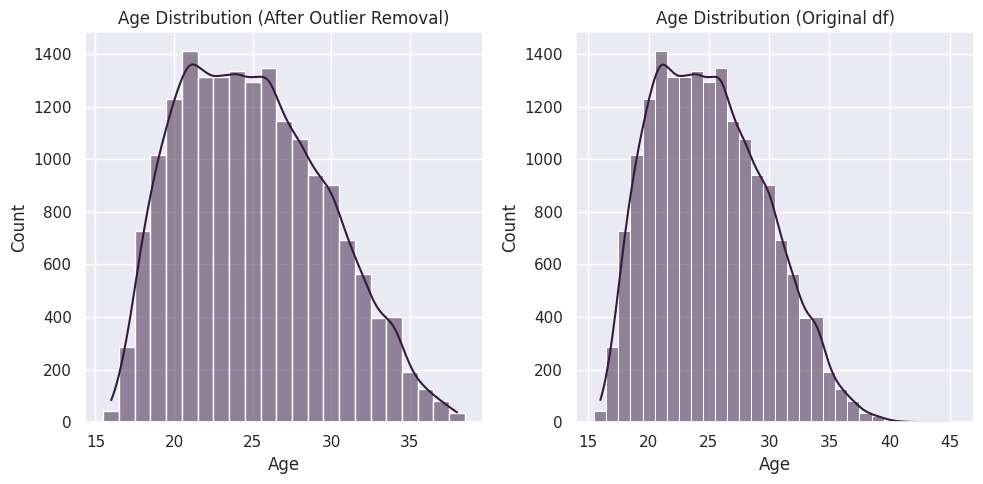

In [257]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(x=NewDf['Age'], discrete=True, legend=False, ax=axes[0], kde=True)
axes[0].set_title("Age Distribution (After Outlier Removal)")
sns.histplot(x=df['Age'], discrete=True, legend=False, ax=axes[1], kde=True)
axes[1].set_title('Age Distribution (Original df)')
plt.tight_layout()
plt.show()

Now we should do the same for the Overall column

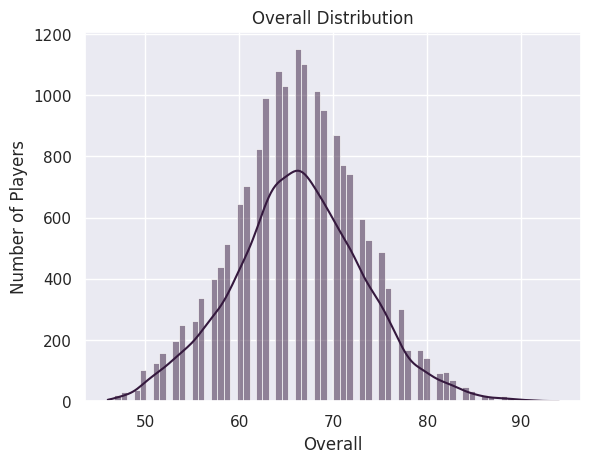

In [341]:
sns.histplot(x=df['Overall'], kde=True)
plt.title("Overall Distribution")
plt.xlabel("Overall")
plt.ylabel("Number of Players")
plt.show()

In [258]:
Q1=df.Overall.quantile(0.25)
Q3=df.Overall.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Overall >= lower_limit) & (df.Overall <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

9.0
48.5
84.5
The data before removing the outliers is(17907, 17)
The data after removing the outliers is(17745, 17)


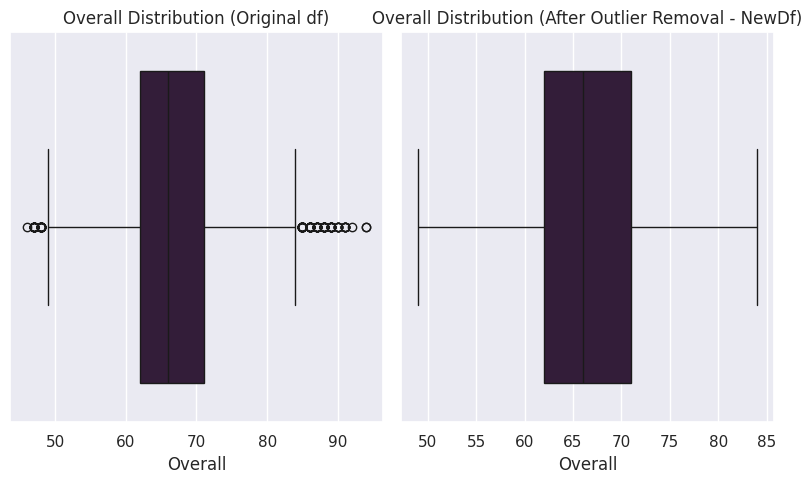

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Overall'], ax=axes[0])
axes[0].set_title("Overall Distribution (Original df)")

sns.boxplot(x=NewDf['Overall'], ax=axes[1])
axes[1].set_title("Overall Distribution (After Outlier Removal - NewDf)")
sns.set_theme(palette='mako')
plt.tight_layout()
plt.show()

In [260]:
print('The statistics before adjustment')
print(df[['Overall']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Overall']].describe())

The statistics before adjustment
            Overall
count  17907.000000
mean      66.239571
std        6.926818
min       46.000000
25%       62.000000
50%       66.000000
75%       71.000000
max       94.000000
--------------------------------
The statistics after adjustment
            Overall
count  17745.000000
mean      66.165061
std        6.683701
min       49.000000
25%       62.000000
50%       66.000000
75%       71.000000
max       84.000000


In [261]:
print('The statistics before adjustment')
print(f"The median of the Overall is {df.Overall.median()}")
print(f"The mode of the Overall is {df.Overall.mode()[0]}")
print("--------------------------------")
print('The statistics before adjustment')
print(f"The median of the Overall is {NewDf.Overall.median()}")
print(f"The mode of the Overall is {NewDf.Overall.mode()[0]}")

The statistics before adjustment
The median of the Overall is 66.0
The mode of the Overall is 66
--------------------------------
The statistics before adjustment
The median of the Overall is 66.0
The mode of the Overall is 66


Based on these numbers, it would be fair to conclude that for the 'Overall' rating, the outliers we identified, while important in their own right, do not have a large overall impact on the mean and standard deviation of the entire player population in this dataset. The central tendency and spread remain quite stable even after removing these extreme values.

This doesn't mean the outliers are unimportant; rather, it suggests that the majority of your data points are clustered in a way that is robust to these extremes, or that the extreme points are balanced out.

### **Calculating Potential Increase**

Let's create a new column `Potential_Increase` to represent the difference between a player's `Potential` and their current `Overall` rating. This metric can give us an idea of how much a player is expected to improve.

In [262]:
df['Potential_Increase'] = df['Potential'] - df['Overall']
display(df[['Name', 'Overall', 'Potential', 'Potential_Increase']].head())

,Name,Overall,Potential,Potential_Increase
0,L. Messi,94,94,0
1,Cristiano Ronaldo,94,94,0
2,Neymar Jr,92,93,1
3,De Gea,91,93,2
4,K. De Bruyne,91,92,1


In [263]:
Q1=df.Potential_Increase.quantile(0.25)
Q3=df.Potential_Increase.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Potential_Increase >= lower_limit) & (df.Potential_Increase <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

9.0
-13.5
22.5
The data before removing the outliers is(17907, 18)
The data after removing the outliers is(17878, 18)


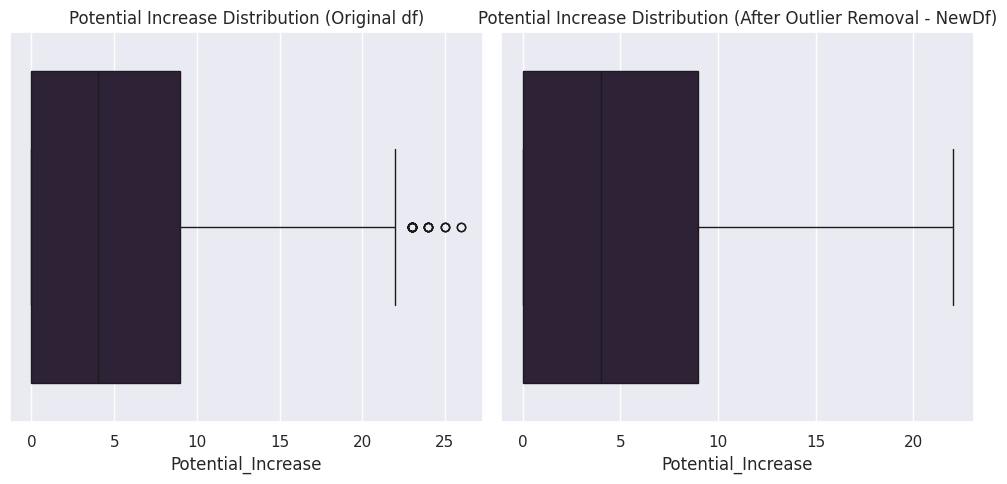

In [264]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(x=df['Potential_Increase'], ax=axes[0])
axes[0].set_title("Potential Increase Distribution (Original df)")
sns.boxplot(x=NewDf['Potential_Increase'], ax=axes[1])
axes[1].set_title("Potential Increase Distribution (After Outlier Removal - NewDf)")
sns.set_theme(palette='rocket')
plt.tight_layout()
plt.show()


In [265]:
print('The statistics before adjustment')
print(df[['Potential_Increase']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Potential_Increase']].describe())

The statistics before adjustment
       Potential_Increase
count        17907.000000
mean             5.095661
std              5.431072
min              0.000000
25%              0.000000
50%              4.000000
75%              9.000000
max             26.000000
--------------------------------
The statistics after adjustment
       Potential_Increase
count        17878.000000
mean             5.065611
std              5.383809
min              0.000000
25%              0.000000
50%              4.000000
75%              9.000000
max             22.000000


In [266]:
print('The statistics before adjustment')
print(f"The median of the Potential_Increase is {df.Potential_Increase.median()}")
print(f"The mode of the Potential_Increase is {df.Potential_Increase.mode()[0]}")
print("--------------------------------")
print('The statistics before adjustment')
print(f"The median of the Potential_Increase is {NewDf.Potential_Increase.median()}")
print(f"The mode of the Potential_Increase is {NewDf.Potential_Increase.mode()[0]}")

The statistics before adjustment
The median of the Potential_Increase is 4.0
The mode of the Potential_Increase is 0
--------------------------------
The statistics before adjustment
The median of the Potential_Increase is 4.0
The mode of the Potential_Increase is 0


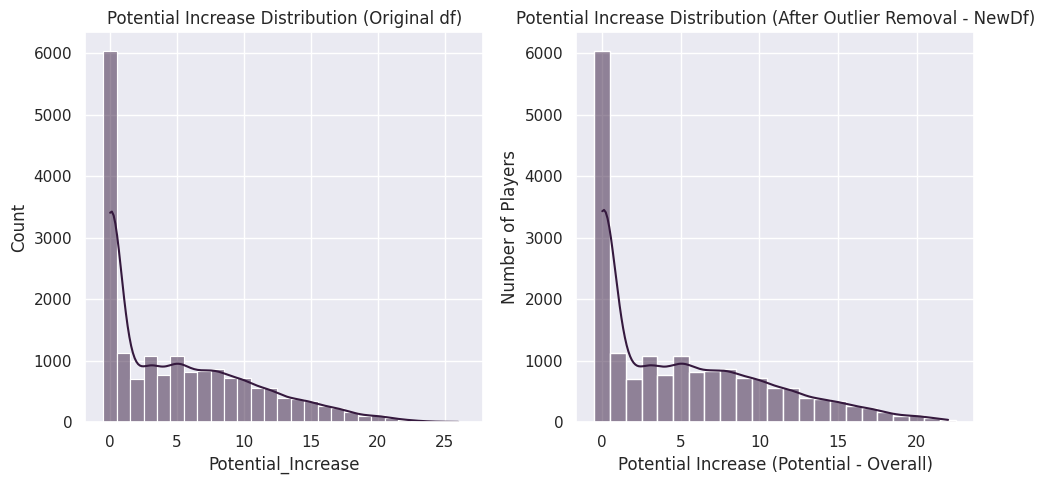

In [267]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['Potential_Increase'], kde=True, discrete=True,ax=axes[0])
axes[0].set_title("Potential Increase Distribution (Original df)")
sns.histplot(NewDf['Potential_Increase'], kde=True, discrete=True,ax=axes[1])
axes[1].set_title("Potential Increase Distribution (After Outlier Removal - NewDf)")
plt.tight_layout()
plt.xlabel('Potential Increase (Potential - Overall)')
plt.ylabel('Number of Players')
plt.show()

**Based on these numbers, it would be fair to conclude that for the 'Potential_Increase', the outliers we identified, while important in their own right, do not have a large overall impact on the mean and standard deviation of the entire player population in this dataset. The central tendency and spread remain quite stable even after removing these extreme values.**

# **NATIONALITIES**

In [268]:
df[['Nationality']].value_counts().sample(10)

,count
Nationality,
Guinea,31
Senegal,130
Paraguay,65
Guatemala,3
Qatar,1
Finland,65
Saudi Arabia,336
Slovenia,50
Australia,234


In [269]:
print(f'There are {df.Nationality.nunique()} nations in the dataset')

There are 163 nations in the dataset


In [270]:
print(f'The nation that has the most players is {df.Nationality.value_counts().index[0]} with {df.Nationality.value_counts().iloc[0]} players')
print(f'The nation that has the least players is {df.Nationality.value_counts(ascending=True).index[0]} with {df.Nationality.value_counts(ascending=True).iloc[0]} players')

The nation that has the most players is England with 1655 players
The nation that has the least players is São Tomé & Príncipe with 1 players


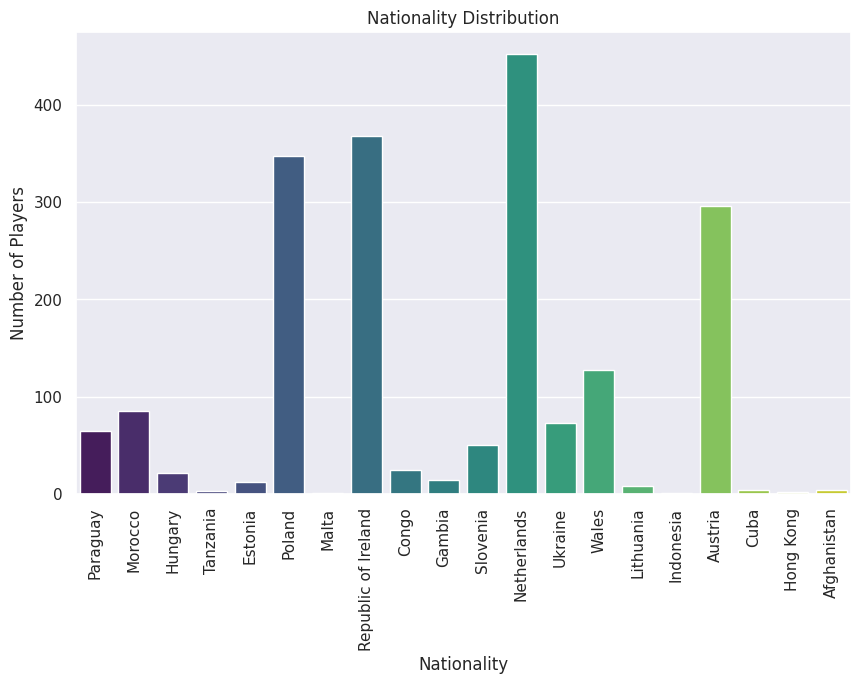

In [271]:
some=df.Nationality.value_counts().sample(20).reset_index()
some.columns=['Nationality','count']
plt.figure(figsize=(10,6))
sns.barplot(x='Nationality',y='count' ,data=some, palette='viridis', hue='Nationality', legend=False)
plt.title("Nationality Distribution")
plt.xlabel("Nationality")
plt.ylabel("Number of Players")
plt.xticks(rotation=90)
plt.show()

# **CLUBS**

In [272]:
df[['Club']].value_counts().sample(10)

,count
Club,
Atlético Nacional,28
Grêmio,20
SV Darmstadt 98,27
Club Brugge KV,28
Curicó Unido,28
Cosenza,30
TSV 1860 München,26
Walsall,27
FC Seoul,28


In [273]:
print(f'There are {df.Club.nunique()} clubs in the dataset')

There are 651 clubs in the dataset


In [274]:
print(f'The club that has the most players is {df.Club.value_counts().index[0]} with {df.Club.value_counts().iloc[0]} players')
print(f'The club that has the least players is {df.Club.value_counts(ascending=True).index[0]} with {df.Club.value_counts(ascending=True).iloc[0]} players')

The club that has the most players is RC Celta with 33 players
The club that has the least players is Derry City with 18 players


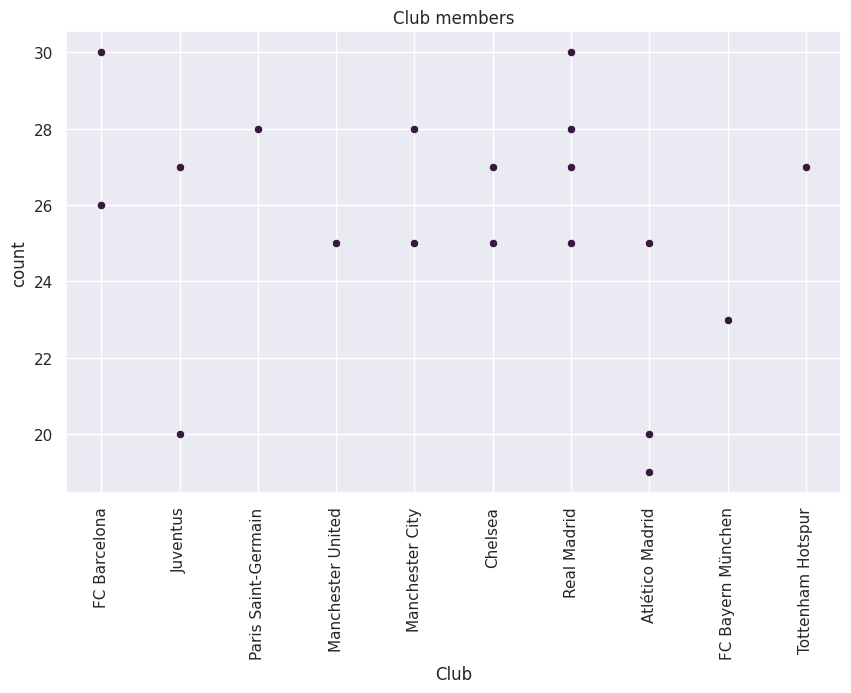

In [275]:
num=df.Club.value_counts().sample(20).reset_index()
num.columns=['Club','count']
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Club', y=num['count'])
plt.title("Club members")
plt.xticks(rotation=90)
plt.show()

# ***Preferred Foot***

*Let us see whether majority of players prefer left foot or right foot*

*It seems most players like prefer to take the shot with their right foot.But still unclear on how many players though*

In [276]:
df[["Preferred Foot"]].value_counts()


,count
Preferred Foot,
Right,13748
Left,4159


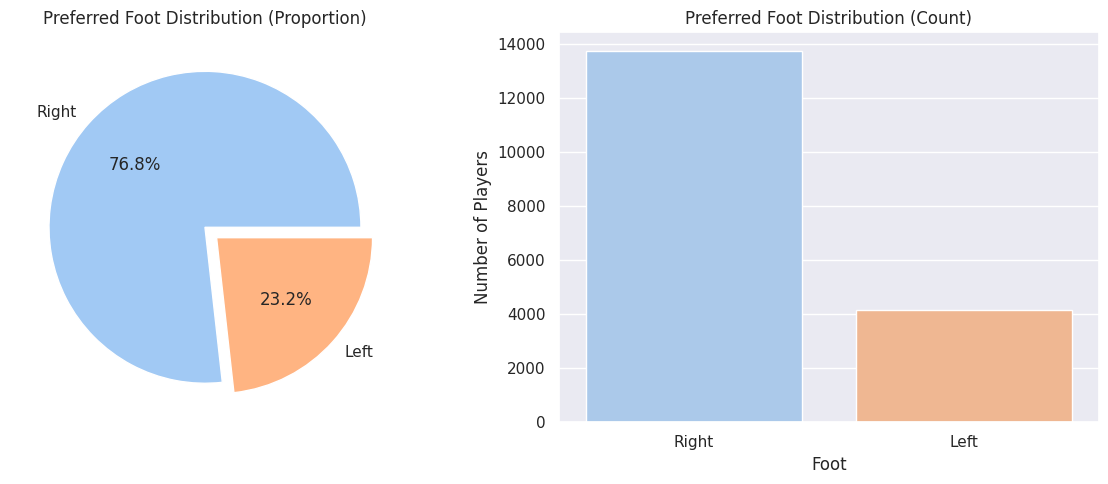

In [277]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
right_count = df['Preferred Foot'].value_counts()['Right']
left_count = df['Preferred Foot'].value_counts()['Left']
data_counts = [right_count, left_count]
keys = ['Right','Left']

explode = [0, 0.1]

palette_color = sns.color_palette('pastel', n_colors=2)

# Pie chart (still uses proportions for its autopct)
axes[0].pie(data_counts, labels=keys, colors=palette_color,
        explode=explode, autopct='%.01f%%')
axes[0].set_title("Preferred Foot Distribution (Proportion)")

# Create a temporary DataFrame for the barplot using raw counts
barplot_data_counts = pd.DataFrame({'Foot': keys, 'Count': data_counts})
sns.barplot(x='Foot', y='Count', hue='Foot', palette=palette_color, legend=False, ax=axes[1], data=barplot_data_counts)
axes[1].set_title("Preferred Foot Distribution (Count)")
axes[1].set_ylabel('Number of Players') # Change y-label for count plot

plt.tight_layout()
plt.show()

*Well now we know. 76.8% of the players prefer right foot *

# ***7.Position they play in***

*Let's find out which position most players play in*

In [278]:
print(f'There are {df.Position.nunique()} positions in the dataset')

There are 27 positions in the dataset


In [279]:
df[["Position"]].value_counts()

,count
Position,
ST,2130
GK,1989
CB,1751
CM,1377
LB,1304
RB,1268
RM,1114
LM,1086
CAM,946


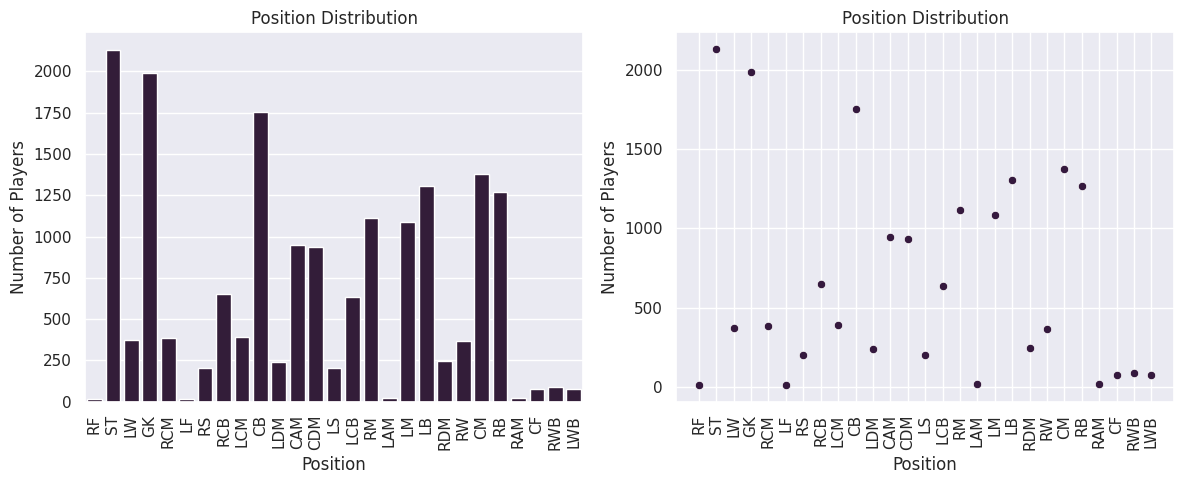

In [280]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
position_counts = df["Position"].value_counts(sort=False).reset_index()
position_counts.columns = ['Position', 'Count']
sns.barplot(x='Position', y='Count', data=position_counts,ax=axes[0])
axes[0].set_title("Position Distribution")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Number of Players")
axes[0].tick_params(axis='x', rotation=90)
sns.scatterplot(x='Position', y='Count', data=position_counts, ax=axes[1])
axes[1].set_title("Position Distribution")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Number of Players")
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

*It seems as though most players play in the ST position*

# **International Reputation**
*Internation Reputation is a huge factor when it comes to a player and the team he is in. Let us take a closer look as to how strong are their reputation on a scale of 1-5*

In [281]:
df["International Reputation"].value_counts()

,count
International Reputation,
1.0,16298
2.0,1245
3.0,307
4.0,51
5.0,6


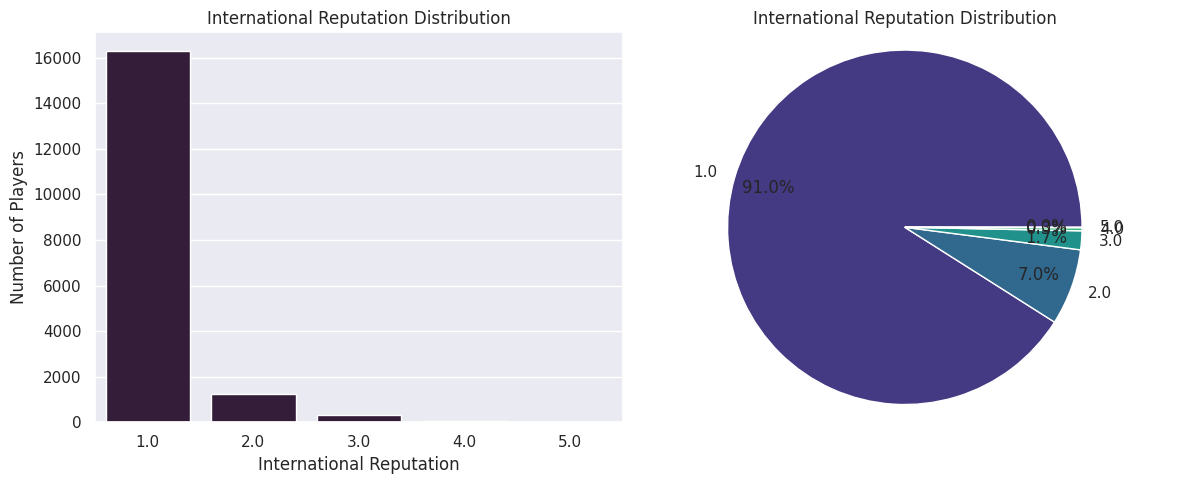

In [282]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.barplot(x=df["International Reputation"].value_counts().index,y=df["International Reputation"].value_counts(),ax=axes[0])
axes[0].set_title("International Reputation Distribution")
axes[0].set_xlabel("International Reputation")
axes[0].set_ylabel("Number of Players")
custom_palette = sns.color_palette('viridis', n_colors=len(df["International Reputation"].value_counts()))
axes[1].pie(df["International Reputation"].value_counts(), labels=df["International Reputation"].value_counts().index, autopct='%1.1f%%', colors=custom_palette, pctdistance=0.8)
axes[1].set_title("International Reputation Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()

*This gives us any early idea as to how many playes have the highest international reputation.*

# ***Skill Moves***
*Skill Moves of a  player directly translates into their performace in a game.*

In [283]:
df[["Skill Moves"]].value_counts()

,count
Skill Moves,
2.0,8439
3.0,6518
1.0,1989
4.0,911
5.0,50


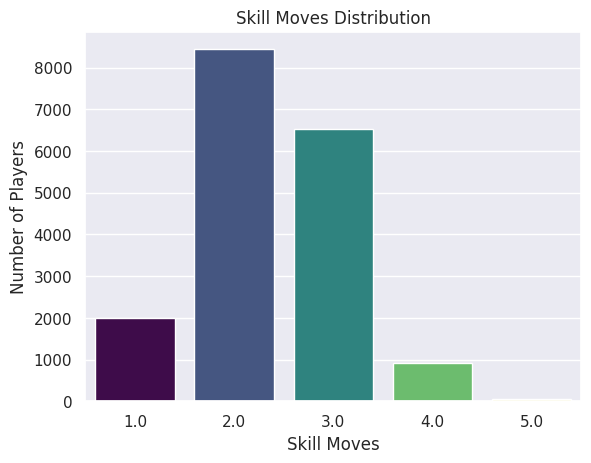

In [284]:
sns.countplot(x='Skill Moves', data=df, hue='Skill Moves', palette='viridis', legend=False)
plt.title("Skill Moves Distribution")
plt.xlabel("Skill Moves")
plt.ylabel("Number of Players")
plt.show()

*Most of the players are of skill set point 2.*

**lets add a Years in club column as we can do some statistics on it**

In [285]:
df['YearsInClub']=2019 - df['Joined']

In [286]:
df[['YearsInClub']].describe()

,YearsInClub
count,17907.000000
mean,2.570447
std,2.027399
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,28.000000


Now lets convert the years in club into some ranges for the Statistics

In [287]:
bins = [1, 6, 11, 20, df['YearsInClub'].max() + 1]
labels = ['1-5','6-10','11-20','>20']
df['YearsInClub_Category'] = pd.cut(df['YearsInClub'], bins=bins, labels=labels, right=False)

In [288]:
df[['YearsInClub_Category']].value_counts()

,count
YearsInClub_Category,
1-5,16534
6-10,1205
11-20,163
>20,5


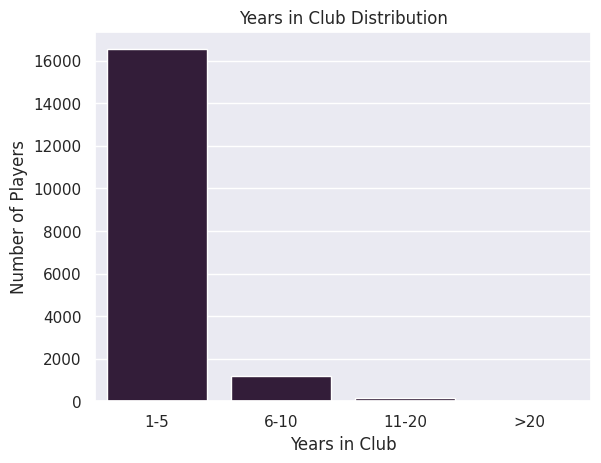

In [289]:
sns.countplot(x='YearsInClub_Category',data=df)
plt.title("Years in Club Distribution")
plt.xlabel("Years in Club")
plt.ylabel("Number of Players")
plt.show()

In [290]:
df

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause,Potential_Increase,YearsInClub,YearsInClub_Category
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0,0,15,11-20
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0,0,1,1-5
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0,1,2,1-5
3,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0,2,8,6-10
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0,1,4,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0,18,2,1-5
18203,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0,16,1,1-5
18204,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0,20,2,1-5
18205,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0,19,1,1-5


# **Height Statistics**

lets remove the outliers and see its impact on the data

In [291]:
Q1=df.Height.quantile(0.25)
Q3=df.Height.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Height >= lower_limit) & (df.Height <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

0.33333333333333304
5.25
6.583333333333332
The data before removing the outliers is(17907, 20)
The data after removing the outliers is(17866, 20)


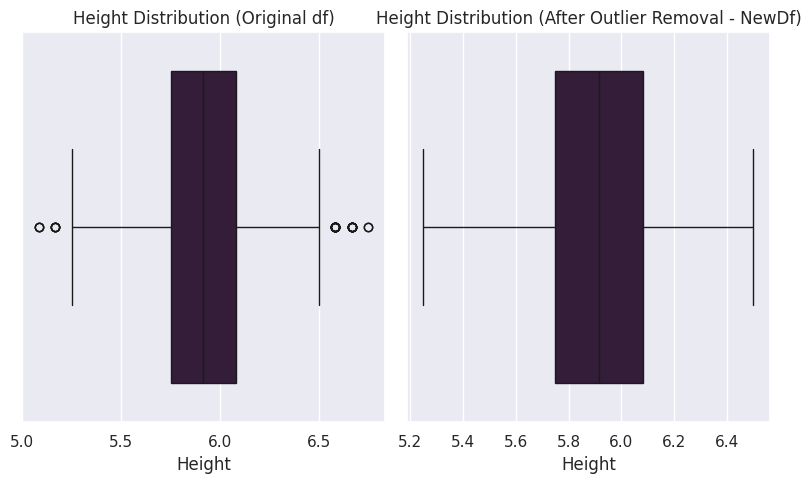

In [292]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Height'], ax=axes[0])
axes[0].set_title("Height Distribution (Original df)")

sns.boxplot(x=NewDf['Height'], ax=axes[1])
axes[1].set_title("Height Distribution (After Outlier Removal - NewDf)")

plt.tight_layout()
plt.show()

In [293]:
print('The statistics before adjustment')
print(df[['Height']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Height']].describe())

The statistics before adjustment
             Height
count  17907.000000
mean       5.946711
std        0.220812
min        5.083333
25%        5.750000
50%        5.916667
75%        6.083333
max        6.750000
--------------------------------
The statistics after adjustment
             Height
count  17866.000000
mean       5.945833
std        0.218483
min        5.250000
25%        5.750000
50%        5.916667
75%        6.083333
max        6.500000


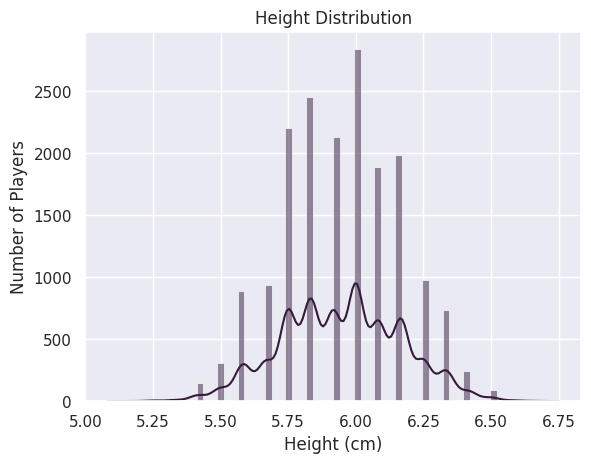

In [294]:
sns.histplot(df['Height'], kde=True)
plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Number of Players")
plt.show()

# **Weight**

In [295]:
Q1=df.Weight.quantile(0.25)
Q3=df.Weight.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Weight >= lower_limit) & (df.Weight <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

22.0
121.0
209.0
The data before removing the outliers is(17907, 20)
The data after removing the outliers is(17833, 20)


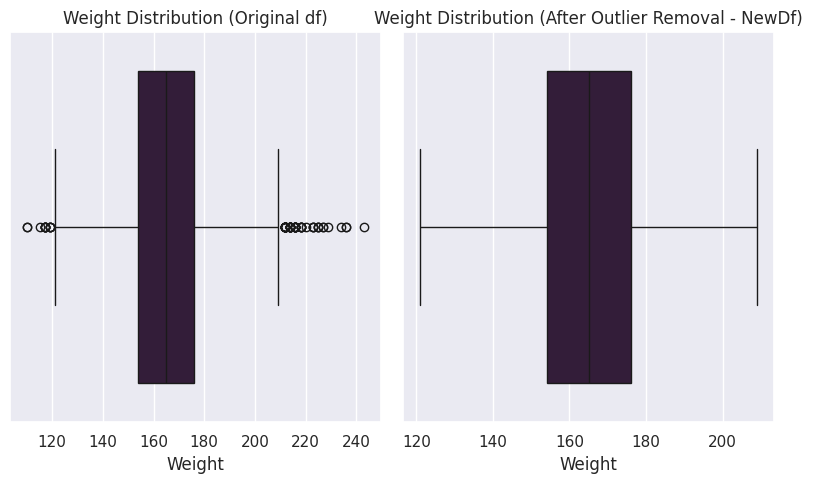

In [296]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Weight'], ax=axes[0])
axes[0].set_title("Weight Distribution (Original df)")

sns.boxplot(x=NewDf['Weight'], ax=axes[1])
axes[1].set_title("Weight Distribution (After Outlier Removal - NewDf)")

plt.tight_layout()
plt.show()

In [297]:
print('The statistics before adjustment')
print(df[['Weight']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Weight']].describe())

The statistics before adjustment
             Weight
count  17907.000000
mean     165.964316
std       15.602524
min      110.000000
25%      154.000000
50%      165.000000
75%      176.000000
max      243.000000
--------------------------------
The statistics after adjustment
             Weight
count  17833.000000
mean     165.825380
std       15.280722
min      121.000000
25%      154.000000
50%      165.000000
75%      176.000000
max      209.000000


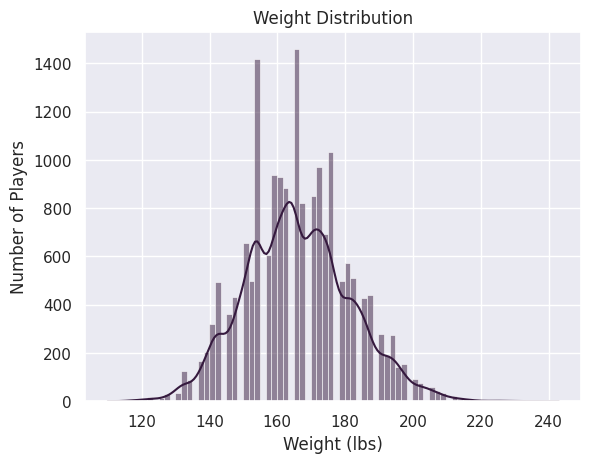

In [298]:
sns.histplot(df['Weight'], kde=True)
plt.title("Weight Distribution")
plt.xlabel("Weight (lbs)")
plt.ylabel("Number of Players")
plt.show()

**Both the outliers in the height and weight columns has almost no impact on the distribution or the centeral of tendency**

In [299]:
df

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause,Potential_Increase,YearsInClub,YearsInClub_Category
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0,0,15,11-20
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0,0,1,1-5
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0,1,2,1-5
3,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0,2,8,6-10
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0,1,4,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0,18,2,1-5
18203,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0,16,1,1-5
18204,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0,20,2,1-5
18205,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0,19,1,1-5


# Value

### **Log Transformation of Player Value**

Given the highly skewed nature of player `Value`, applying a logarithmic transformation can help normalize its distribution, making it more amenable to statistical analysis and visualization. We'll create a new column, `Log_Value`, for this.

In [300]:
df['Log_Value'] = np.log1p(df['Value']) # Using log1p to handle potential zero values gracefully

# Display the head of the new column along with the original value
display(df[['Value', 'Log_Value']].head())

,Value,Log_Value
0,110500.0,11.612780
1,77000.0,11.251574
2,118500.0,11.682677
3,72000.0,11.184435
4,102000.0,11.532738


### **Comparing Distributions: Original Value vs. Log-Transformed Value**

Let's visualize the distribution of both the original `Value` and the new `Log_Value` to see the effect of the transformation.

In [301]:
print('The statistics of original Value')
print(df[['Value']].describe())
print("--------------------------------")
print('The statistics of Log_Value (before outlier adjustment)')
print(df[['Log_Value']].describe())

The statistics of original Value
               Value
count   17907.000000
mean     2450.132909
std      5633.206685
min        10.000000
25%       325.000000
50%       700.000000
75%      2100.000000
max    118500.000000
--------------------------------
The statistics of Log_Value (before outlier adjustment)
          Log_Value
count  17907.000000
mean       6.717862
std        1.404025
min        2.397895
25%        5.786897
50%        6.552508
75%        7.650169
max       11.682677


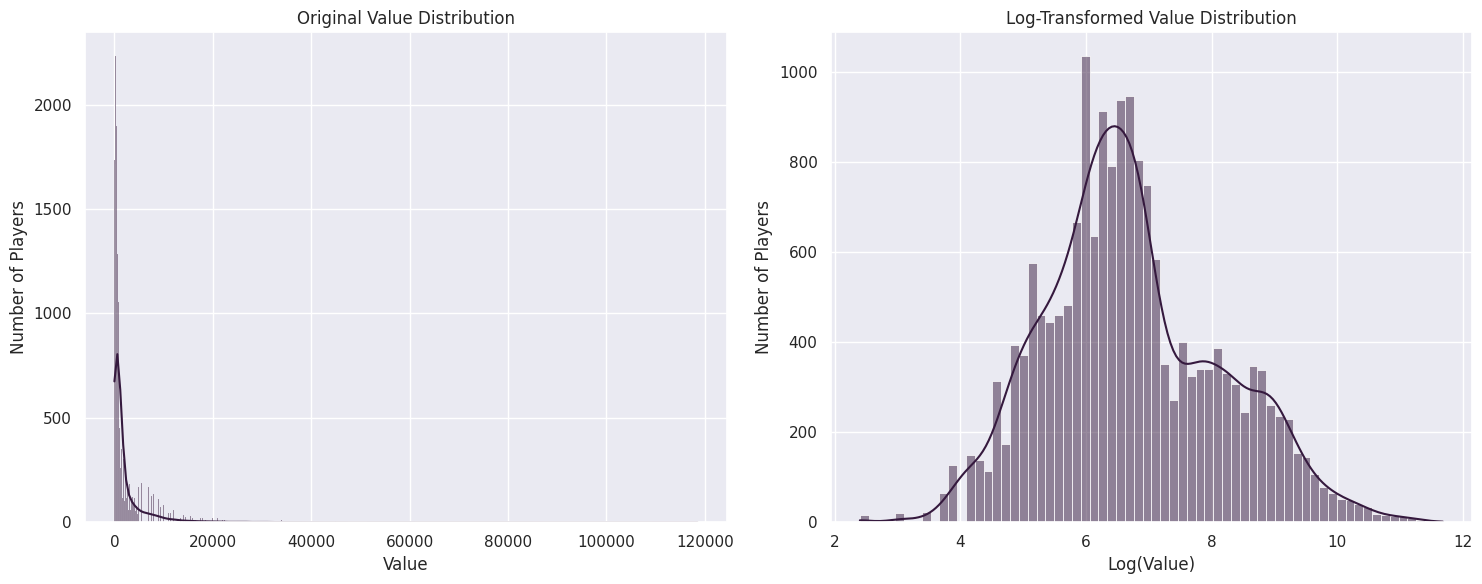

In [302]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Value'], kde=True, ax=axes[0])
axes[0].set_title('Original Value Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Number of Players')

sns.histplot(df['Log_Value'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Value Distribution')
axes[1].set_xlabel('Log(Value)')
axes[1].set_ylabel('Number of Players')

plt.tight_layout()
plt.show()

Now lets check for the outliers impact

In [303]:
Q1=df.Log_Value.quantile(0.25)
Q3=df.Log_Value.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Log_Value >= lower_limit) & (df.Log_Value <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')


1.8632713194782928
2.9919904021492685
10.44507568006244
The data before removing the outliers is(17907, 21)
The data after removing the outliers is(17790, 21)


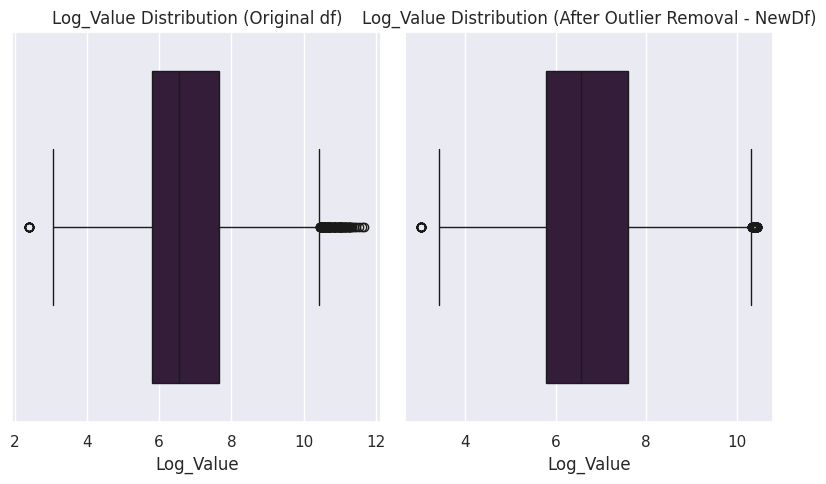

In [304]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Log_Value'], ax=axes[0])
axes[0].set_title("Log_Value Distribution (Original df)")

sns.boxplot(x=NewDf['Log_Value'], ax=axes[1])
axes[1].set_title("Log_Value Distribution (After Outlier Removal - NewDf)")

plt.tight_layout()
plt.show()

In [305]:
print('The statistics before adjustment')
print(df[['Log_Value']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Log_Value']].describe())

The statistics before adjustment
          Log_Value
count  17907.000000
mean       6.717862
std        1.404025
min        2.397895
25%        5.786897
50%        6.552508
75%        7.650169
max       11.682677
--------------------------------
The statistics after adjustment
          Log_Value
count  17790.000000
mean       6.697902
std        1.367646
min        3.044522
25%        5.786897
50%        6.552508
75%        7.601402
max       10.434145


# **Wage**

# Log Transformation of Player Wage

**Given the highly skewed nature of player wage, applying a logarithmic transformation can help normalize its distribution, making it more amenable to statistical analysis and visualization. We'll create a new column, Log_Wage, for this.**

In [306]:
df['Log_Wage'] = np.log1p(df['Wage'])
display(df[['Wage', 'Log_Wage']].head())

,Wage,Log_Wage
0,565.0,6.338594
1,405.0,6.006353
2,290.0,5.673323
3,260.0,5.564520
4,355.0,5.874931


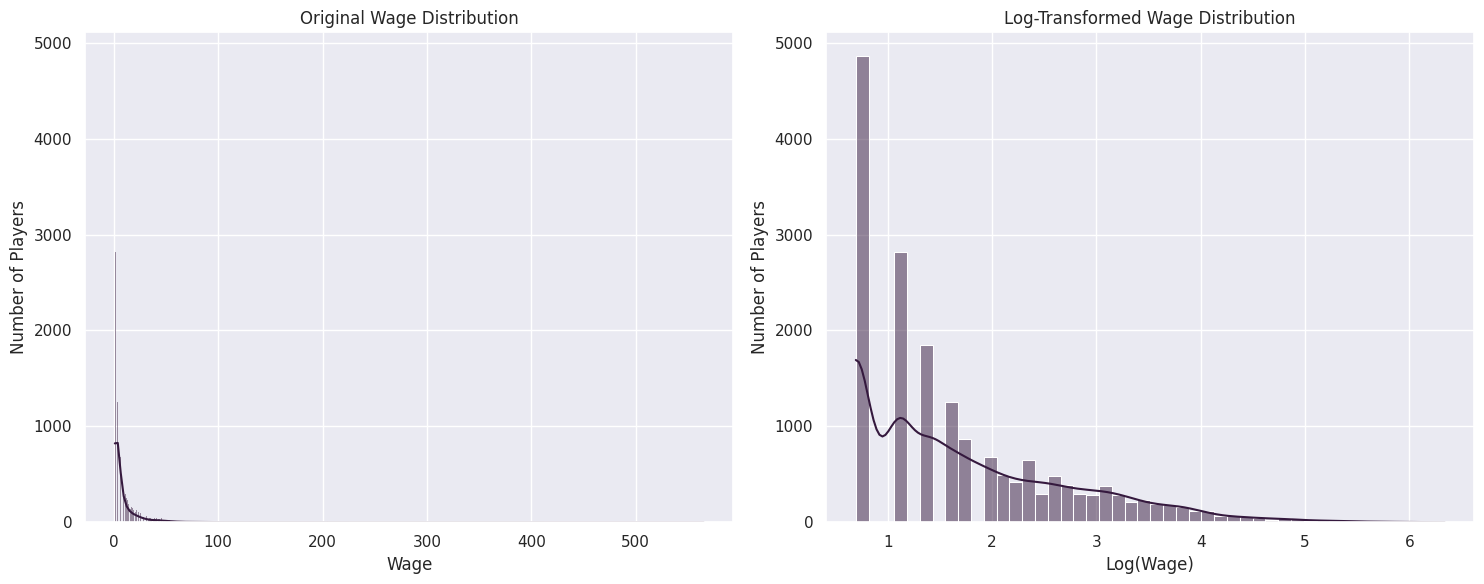

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Wage'], kde=True, ax=axes[0])
axes[0].set_title('Original Wage Distribution')
axes[0].set_xlabel('Wage')
axes[0].set_ylabel('Number of Players')

sns.histplot(df['Log_Wage'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Wage Distribution')
axes[1].set_xlabel('Log(Wage)')
axes[1].set_ylabel('Number of Players')

plt.tight_layout()
plt.show()

Now lets check for the outliers impact

In [308]:
Q1=df.Log_Wage.quantile(0.25)
Q3=df.Log_Wage.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Log_Wage >= lower_limit) & (df.Log_Wage <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')


1.6094379124341005
-1.7210096880912054
4.716741961645196
The data before removing the outliers is(17907, 22)
The data after removing the outliers is(17750, 22)


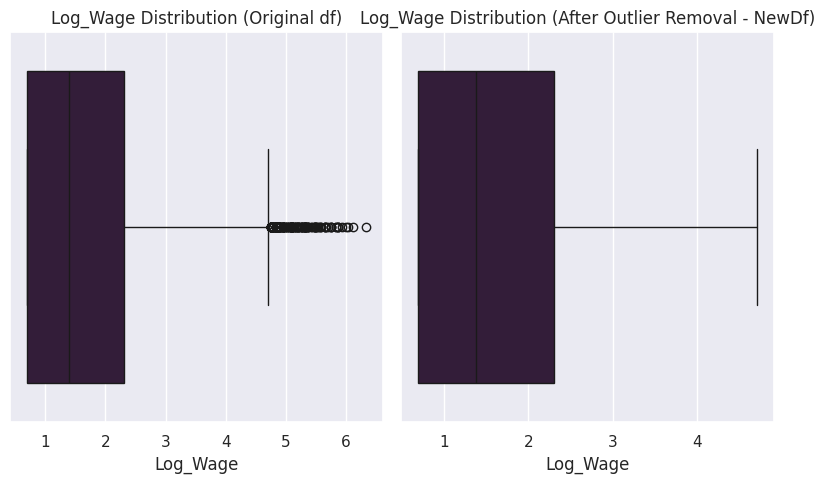

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x=df['Log_Wage'], ax=axes[0])
axes[0].set_title("Log_Wage Distribution (Original df)")

sns.boxplot(x=NewDf['Log_Wage'], ax=axes[1])
axes[1].set_title("Log_Wage Distribution (After Outlier Removal - NewDf)")

plt.tight_layout()
plt.show()

In [310]:
print('The statistics before adjustment')
print(df[['Log_Wage']].describe())
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Log_Wage']].describe())

The statistics before adjustment
           Log_Wage
count  17907.000000
mean       1.703486
std        1.007990
min        0.693147
25%        0.693147
50%        1.386294
75%        2.302585
max        6.338594
--------------------------------
The statistics after adjustment
           Log_Wage
count  17750.000000
mean       1.673144
std        0.958617
min        0.693147
25%        0.693147
50%        1.386294
75%        2.302585
max        4.709530


## Log Transform Release Clause
Apply a logarithmic transformation (`np.log1p`) to the 'Release Clause' column to normalize its distribution, creating a new column called `Log_Release_Clause`. Display the head of this new column along with the original 'Release Clause' to show the transformation.


In [311]:
df['Log_Release_Clause'] = np.log1p(df['Release Clause'])
display(df[['Release Clause', 'Log_Release_Clause']].head())

,Release Clause,Log_Release_Clause
0,226500.0,12.330505
1,127100.0,11.752737
2,228100.0,12.337544
3,138600.0,11.839355
4,196400.0,12.187914


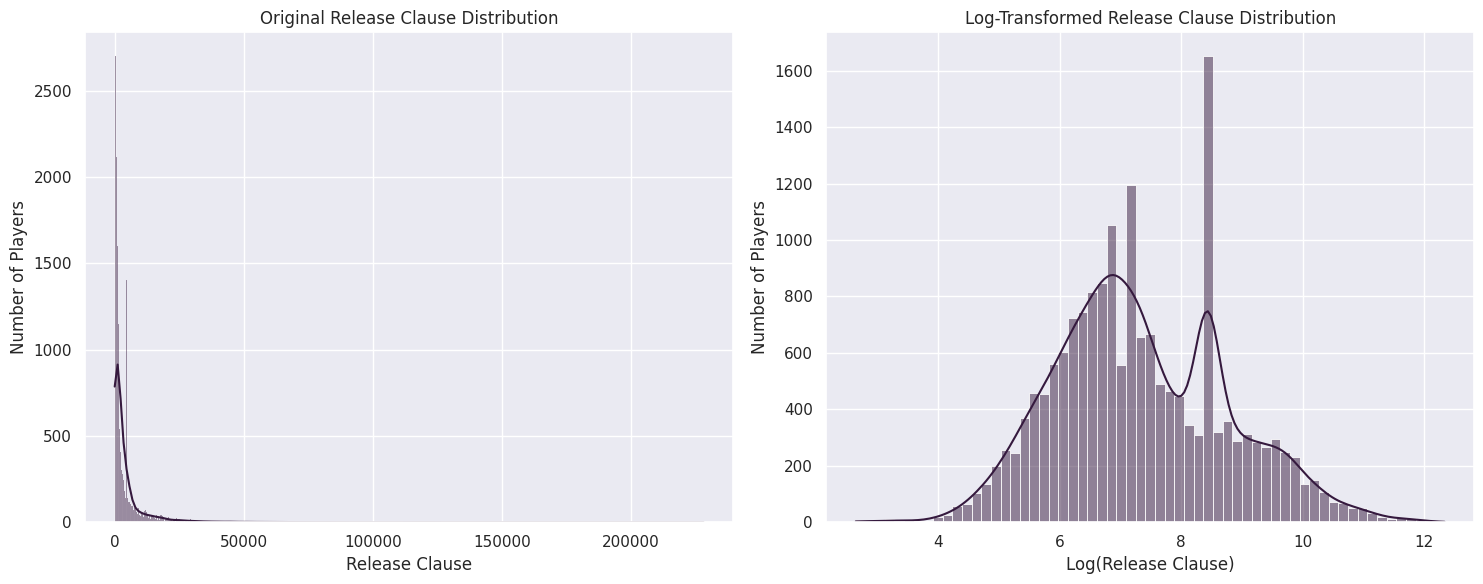

In [312]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df['Release Clause'], kde=True, ax=axes[0])
axes[0].set_title('Original Release Clause Distribution')
axes[0].set_xlabel('Release Clause')
axes[0].set_ylabel('Number of Players')
sns.histplot(df['Log_Release_Clause'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Release Clause Distribution')
axes[1].set_xlabel('Log(Release Clause)')
axes[1].set_ylabel('Number of Players')
plt.tight_layout()
plt.show()

In [313]:
Q1 = df.Log_Release_Clause.quantile(0.25)
Q3 = df.Log_Release_Clause.quantile(0.75)
IQR = Q3 - Q1
print(f"IQR: {IQR}")

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")

NewDf = df[(df.Log_Release_Clause >= lower_limit) & (df.Log_Release_Clause <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

IQR: 2.0957224709564013
Lower Limit: 3.1914705450634573
Upper Limit: 11.574360428889062
The data before removing the outliers is(17907, 23)
The data after removing the outliers is(17855, 23)


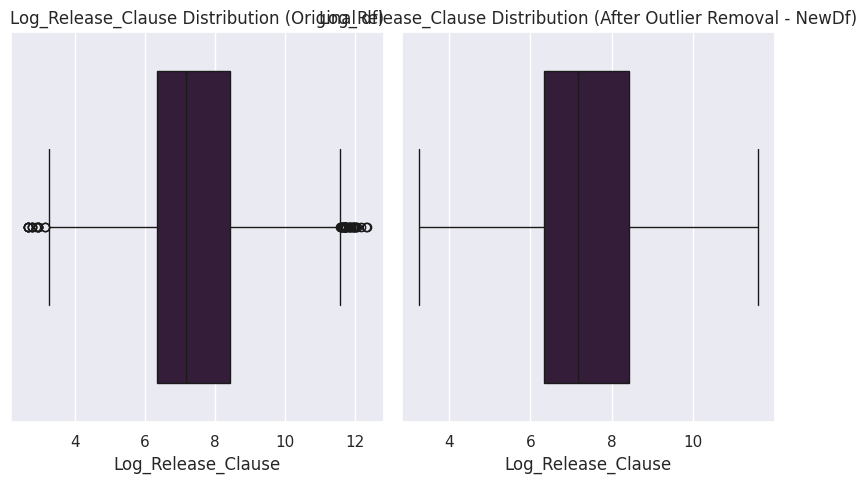

In [314]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.boxplot(x=df['Log_Release_Clause'], ax=axes[0])
axes[0].set_title("Log_Release_Clause Distribution (Original df)")
sns.boxplot(x=NewDf['Log_Release_Clause'], ax=axes[1])
axes[1].set_title("Log_Release_Clause Distribution (After Outlier Removal - NewDf)")
plt.tight_layout()
plt.show()

In [315]:
print('The statistics before adjustment')
print(df[['Log_Release_Clause']].describe())
print(f"The median of the Log_Release_Clause is {df.Log_Release_Clause.median()}")
print(f"The mode of the Log_Release_Clause is {df.Log_Release_Clause.mode()[0]}")
print("--------------------------------")
print('The statistics after adjustment')
print(NewDf[['Log_Release_Clause']].describe())
print(f"The median of the Log_Release_Clause is {NewDf.Log_Release_Clause.median()}")
print(f"The mode of the Log_Release_Clause is {NewDf.Log_Release_Clause.mode()[0]}")

The statistics before adjustment
       Log_Release_Clause
count        17907.000000
mean             7.340291
std              1.424600
min              2.639057
25%              6.335054
50%              7.170888
75%              8.430777
max             12.337544
The median of the Log_Release_Clause is 7.170888478512505
The mode of the Log_Release_Clause is 8.43077672245446
--------------------------------
The statistics after adjustment
       Log_Release_Clause
count        17855.000000
mean             7.334782
std              1.405866
min              3.258097
25%              6.335054
50%              7.170888
75%              8.430777
max             11.574030
The median of the Log_Release_Clause is 7.170888478512505
The mode of the Log_Release_Clause is 8.43077672245446


## **Comprehensive Conclusion: Impact of Log Transformation and Outlier Removal on Value, Wage, and Release Clause**

Throughout our exploratory data analysis, the 'Value', 'Wage', and 'Release Clause' columns consistently presented highly skewed distributions. This skewness, characterized by a large number of lower values and a long tail of extreme high values, posed challenges for standard statistical analysis and effective outlier detection using traditional methods like the IQR. To address this, we systematically applied a logarithmic transformation (`np.log1p`) to each of these columns, creating `Log_Value`, `Log_Wage`, and `Log_Release_Clause`.

**Key Observations Across All Three Columns:**

1.  **Effective Normalization via Log Transformation:** For all three metrics, the `np.log1p` transformation proved highly effective in normalizing their distributions. Histograms of the log-transformed data consistently showed a more symmetrical, bell-shaped curve, significantly reducing the right-skewness observed in the original data. This transformation is crucial as it makes the data more amenable to statistical models that assume normality or require less skewed input.

2.  **Refined Outlier Detection:** Following the log transformation, IQR-based outlier detection was applied to each of the `Log_` columns. This process successfully identified and removed a small percentage of extreme values (between 52 and 157 rows across the three columns). The box plots clearly illustrated the trimming of these outliers, resulting in cleaner distributions with more tightly defined whiskers.

3.  **Stability of Central Tendency:** Despite the removal of these outliers, the central tendency measures (mean, median, and mode) for the log-transformed 'Value', 'Wage', and 'Release Clause' remained remarkably stable. The changes observed in these statistics were consistently minor, indicating that the bulk of the player population's characteristics for these attributes were robust and not significantly distorted by the extreme values.

4.  **Reduced Variability:** A slight but consistent reduction in the standard deviation was observed for each `Log_` column after outlier removal. This signifies that the spread of the data became marginally tighter, confirming the successful elimination of the most distant data points.

**Overall Takeaway:** The sequential process of applying logarithmic transformation followed by IQR-based outlier removal has been highly beneficial for the 'Value', 'Wage', and 'Release Clause' columns. This has transformed them from difficult-to-analyze, highly skewed raw data into more normally distributed, cleaner features. These `Log_` columns are now robustly prepared for more advanced analytical tasks, such as correlation studies, regression modeling, or any analysis requiring assumptions of normality, ensuring that statistical inferences drawn from them will be more reliable and less influenced by extreme, unrepresentative values.

# **Now we have done the EDA for the single column(feature)**
**We need to complete our EDA with joining more than on feature at once and see the realtionship between diffrent columns**

In [316]:
df

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,Contract Valid Until,Height,Weight,Release Clause,Potential_Increase,YearsInClub,YearsInClub_Category,Log_Value,Log_Wage,Log_Release_Clause
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,...,2021-01-01,5.583333,159.0,226500.0,0,15,11-20,11.612780,6.338594,12.330505
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,...,2022-01-01,6.166667,183.0,127100.0,0,1,1-5,11.251574,6.006353,11.752737
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,...,2022-01-01,5.750000,150.0,228100.0,1,2,1-5,11.682677,5.673323,12.337544
3,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,...,2020-01-01,6.333333,168.0,138600.0,2,8,6-10,11.184435,5.564520,11.839355
4,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,...,2023-01-01,5.916667,154.0,196400.0,1,4,1-5,11.532738,5.874931,12.187914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,...,2019-01-01,5.750000,134.0,143.0,18,2,1-5,4.110874,0.693147,4.969813
18203,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,...,2020-01-01,6.250000,170.0,113.0,16,1,1-5,4.110874,0.693147,4.736198
18204,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,...,2021-01-01,5.666667,148.0,165.0,20,2,1-5,4.110874,0.693147,5.111988
18205,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,...,2019-01-01,5.833333,154.0,143.0,19,1,1-5,4.110874,0.693147,4.969813


We want to see the impact of Age on the diffrent columns so we need to cut it into ranges for better calculations

In [342]:
bins=[16, 19, 22, 25, 28, 31, 34, 37, df['Age'].max() + 1]
labels=["[16-18]", "[19-21]", "[22-24]", "[25-27]", "[28-30]", "[31-33]", "[34-36]", ">36"]
df['AgeRange']=pd.cut(df['Age'],bins=bins,labels=labels,right=False)
NewDf['AgeRange']=pd.cut(NewDf['Age'],bins=bins,labels=labels,right=False)

/tmp/ipython-input-1653191630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NewDf['AgeRange']=pd.cut(NewDf['Age'],bins=bins,labels=labels,right=False)


In [343]:
df[['AgeRange']].value_counts()

,count
AgeRange,
[22-24],3959
[25-27],3788
[19-21],3658
[28-30],2919
[31-33],1656
[16-18],1058
[34-36],718
>36,151


In [346]:
df.groupby('AgeRange')[['Overall','Potential_Increase']].agg(['mean','median','max','min'])

/tmp/ipython-input-1846472288.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeRange')[['Overall','Potential_Increase']].agg(['mean','median','max','min'])


Overall                Potential_Increase               
               mean median max min               mean median max min
AgeRange                                                            
[16-18]   57.224953   57.0  82  46          16.486767   17.0  26   3
[19-21]   61.851558   61.0  88  47          11.247130   11.0  21   2
[22-24]   66.207881   66.0  89  48           6.296287    6.0  13   1
[25-27]   68.511352   68.0  92  50           1.949314    2.0   7   0
[28-30]   69.380610   69.0  90  51           0.120589    0.0   3   0
[31-33]   69.691425   69.0  94  48           0.000000    0.0   0   0
[34-36]   68.877437   69.0  86  53           0.000000    0.0   0   0
>36       68.423841   69.0  88  52           0.000000    0.0   0   0

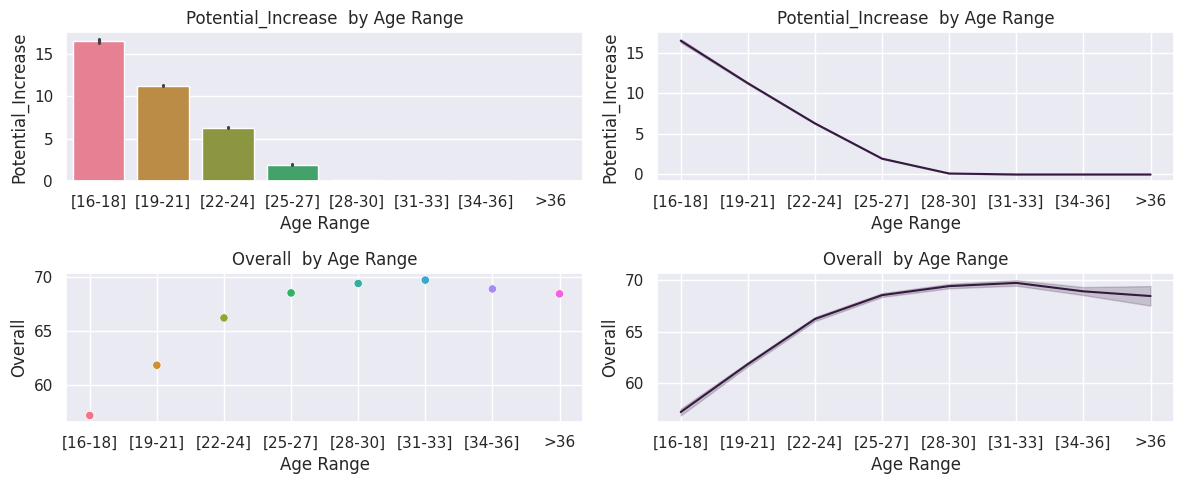

In [368]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
sns.barplot(x='AgeRange',y='Potential_Increase',data=df,ax=axes[0][0],hue='AgeRange',legend=False)
axes[0][0].set_title("Potential_Increase  by Age Range")
axes[0][0].set_xlabel("Age Range")
axes[0][0].set_ylabel("Potential_Increase")
sns.lineplot(x='AgeRange',y='Potential_Increase',data=df,ax=axes[0][1])
axes[0][1].set_title("Potential_Increase  by Age Range")
axes[0][1].set_xlabel("Age Range")
axes[0][1].set_ylabel("Potential_Increase")
sns.scatterplot(x='AgeRange',y='Overall',data=df.groupby('AgeRange', observed=False)['Overall'].mean().reset_index(),ax=axes[1][0],hue='AgeRange',legend=False)
axes[1][0].set_title("Overall  by Age Range")
axes[1][0].set_xlabel("Age Range")
axes[1][0].set_ylabel("Overall")
sns.lineplot(x='AgeRange',y='Overall',data=df,ax=axes[1][1])
axes[1][1].set_title("Overall  by Age Range")
axes[1][1].set_xlabel("Age Range")
axes[1][1].set_ylabel("Overall")
plt.tight_layout()
plt.show()

Here we conclude that the young players have a greater Potential_Increase than older players and that after 30's the players almost haven't any potential to increase

In [338]:
df.groupby('AgeRange')[['Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean'])

/tmp/ipython-input-1340308493.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeRange')[['Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean'])


,Log_Value,Log_Wage,Log_Release_Clause
,mean,mean,mean
AgeRange,,,
[16-18],5.446705,0.955267,6.283482
[19-21],6.207713,1.293829,6.997972
[22-24],6.859843,1.654141,7.492218
[25-27],7.175455,1.931280,7.722666
[28-30],7.161500,2.050668,7.681519
[31-33],6.934356,2.032188,7.444863
[34-36],6.041873,1.825023,6.543745
>36,5.045109,1.555153,5.506423


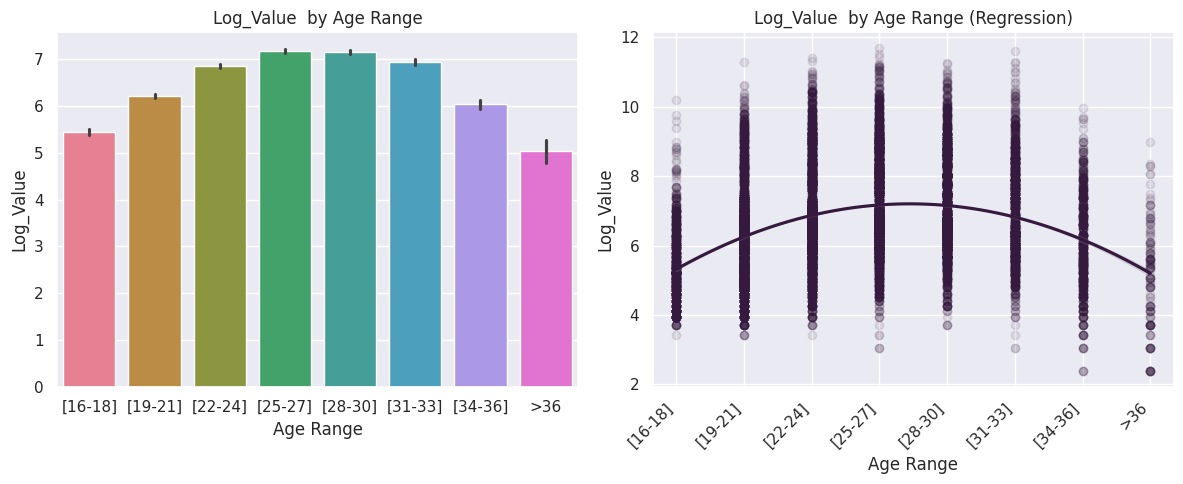

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='AgeRange',y='Log_Value',data=df,ax=axes[0],hue='AgeRange',legend=False)
axes[0].set_title("Log_Value  by Age Range")
axes[0].set_xlabel("Age Range")
axes[0].set_ylabel("Log_Value")

age_range_codes = df['AgeRange'].cat.codes
age_range_labels = df['AgeRange'].cat.categories

sns.regplot(x=age_range_codes, y='Log_Value', data=df, ax=axes[1], order=2, scatter_kws={'alpha':0.1})
axes[1].set_title("Log_Value  by Age Range (Regression)")
axes[1].set_xlabel("Age Range")
axes[1].set_ylabel("Log_Value")
axes[1].set_xticks(range(len(age_range_labels)))
axes[1].set_xticklabels(age_range_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

Financial data suggests a 'prime-age' premium. Young prospects (16–18) carry lower valuations due to unproven potential, while veteran players (32+) see a drop in market value due to decreased longevity. The 'Sweet Spot' for a player’s market worth lies in the 22–31 age bracket.

In [350]:
df.groupby('AgeRange')['YearsInClub'].agg(['mean'])

/tmp/ipython-input-3464669230.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeRange')['YearsInClub'].agg(['mean'])


,mean
AgeRange,
[16-18],1.563327
[19-21],2.257244
[22-24],2.519323
[25-27],2.538279
[28-30],2.758136
[31-33],3.282005
[34-36],3.227019
>36,4.807947


/tmp/ipython-input-2097313836.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='AgeRange',y='YearsInClub',data=df, ax=axes[0], palette='viridis')


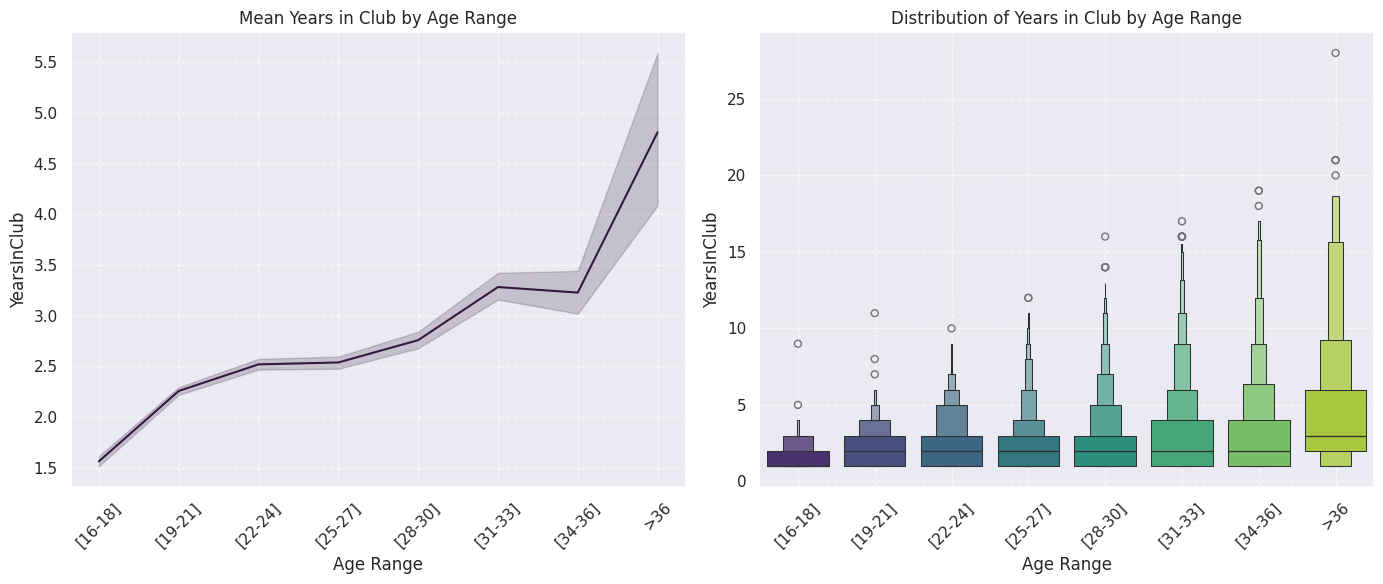

In [373]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.lineplot(x='AgeRange',y='YearsInClub',data=df, ax=axes[0], palette='viridis')
axes[0].set_title("Mean Years in Club by Age Range")
axes[0].set_xlabel("Age Range")
axes[0].set_ylabel("YearsInClub")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

sns.boxenplot(x='AgeRange',y='YearsInClub',data=df, ax=axes[1], hue='AgeRange', legend=False, palette='viridis')
axes[1].set_title("Distribution of Years in Club by Age Range")
axes[1].set_xlabel("Age Range")
axes[1].set_ylabel("YearsInClub")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

There is an increasing, but not perfectly linear, relationship. between age range and years in the club as for the increase in age the years he has been in the club increase

We will get our Top 10 Nations and see the impact of the nationality on the diffrent columns

In [384]:
top_10_nations = df['Nationality'].value_counts().head(10).index.tolist()
nations = df[df['Nationality'].isin(top_10_nations)]
display(nations.head())

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,Height,Weight,Release Clause,Potential_Increase,YearsInClub,YearsInClub_Category,Log_Value,Log_Wage,Log_Release_Clause,AgeRange
0,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,...,5.583333,159.0,226500.0,0,15,11-20,11.612780,6.338594,12.330505,[31-33]
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,...,5.750000,150.0,228100.0,1,2,1-5,11.682677,5.673323,12.337544,[25-27]
3,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,...,6.333333,168.0,138600.0,2,8,6-10,11.184435,5.564520,11.839355,[25-27]
8,Sergio Ramos,32,Spain,91,91,Real Madrid,51000.0,380.0,Right,4.0,...,6.000000,181.0,104600.0,0,14,11-20,10.839601,5.942799,11.557908,[31-33]
11,T. Kroos,28,Germany,90,90,Real Madrid,76500.0,355.0,Right,4.0,...,6.000000,168.0,156800.0,0,5,1-5,11.245059,5.874931,11.962733,[28-30]


In [386]:
nations.groupby('Nationality')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase                 \
                  mean median max min               mean median max min   
Nationality                                                               
Argentina    68.566845   69.0  94  51           4.634225    2.0  23   0   
Brazil       71.265777   71.0  92  48           2.081311    0.0  22   0   
Colombia     65.591870   66.0  88  48           5.476423    4.0  24   0   
England      63.450151   63.0  89  46           6.623565    5.0  25   0   
France       67.814286   68.0  89  50           5.650549    5.0  24   0   
Germany      66.097071   66.0  90  47           5.604184    5.0  25   0   
Italy        68.184549   68.0  89  47           4.527897    2.0  24   0   
Japan        62.625263   63.0  81  47           4.037895    2.0  21   0   
Netherlands  67.665929   67.0  86  54           5.345133    4.0  20   0   
Spain        69.705882   69.0  91  51           4.915966    4.0  21   0   

            Log_Value                                 Log_Wage            \
                 mean    median        max       min      mean    median   
Nationality                                                                
Argentina    7.128793  7.003974  11.612780  3.044522  1.972270  1.945910   
Brazil       7.587329  7.550135  11.682677  4.110874  2.368050  2.397895   
Colombia     6.589100  6.516193  11.149096  3.713572  1.175286  0.693147   
England      6.222458  6.111467  11.332614  2.397895  1.713088  1.386294   
France       7.086020  6.775366  11.302217  3.044522  1.954038  1.609438   
Germany      6.719629  6.516193  11.245059  2.397895  1.652452  1.386294   
Italy        7.050178  6.803505  11.034906  2.397895  1.876935  1.386294   
Japan        5.844471  5.860786   9.770013  2.397895  1.155976  1.098612   
Netherlands  7.054809  6.789436  10.703267  2.397895  1.788991  1.609438   
Spain        7.440572  7.090910  11.205054  4.110874  2.129451  1.945910   

                                Log_Release_Clause                       \
                  max       min               mean    median        max   
Nationality                                                               
Argentina    6.338594  0.693147           7.696788  7.696667  12.330505   
Brazil       5.831882  0.693147           8.202989  8.229689  12.337544   
Colombia     5.755742  0.693147           7.066797  7.003974  11.089821   
England      5.327876  0.693147           7.059013  6.908755  11.987301   
France       5.484797  0.693147           7.779811  7.496097  12.020351   
Germany      5.874931  0.693147           7.296780  7.090910  11.962733   
Italy        5.375278  0.693147           7.704012  7.696667  11.570260   
Japan        4.189655  0.693147           6.231238  6.137727  10.379753   
Netherlands  5.111988  0.693147           7.593211  7.313887  11.383966   
Spain        5.942799  0.693147           8.100025  7.937732  11.958899   

                       
                  min  
Nationality            
Argentina    3.401197  
Brazil       4.997212  
Colombia     4.007333  
England      2.944439  
France       3.583519  
Germany      2.772589  
Italy        2.772589  
Japan        2.639057  
Netherlands  2.772589  
Spain        4.543295

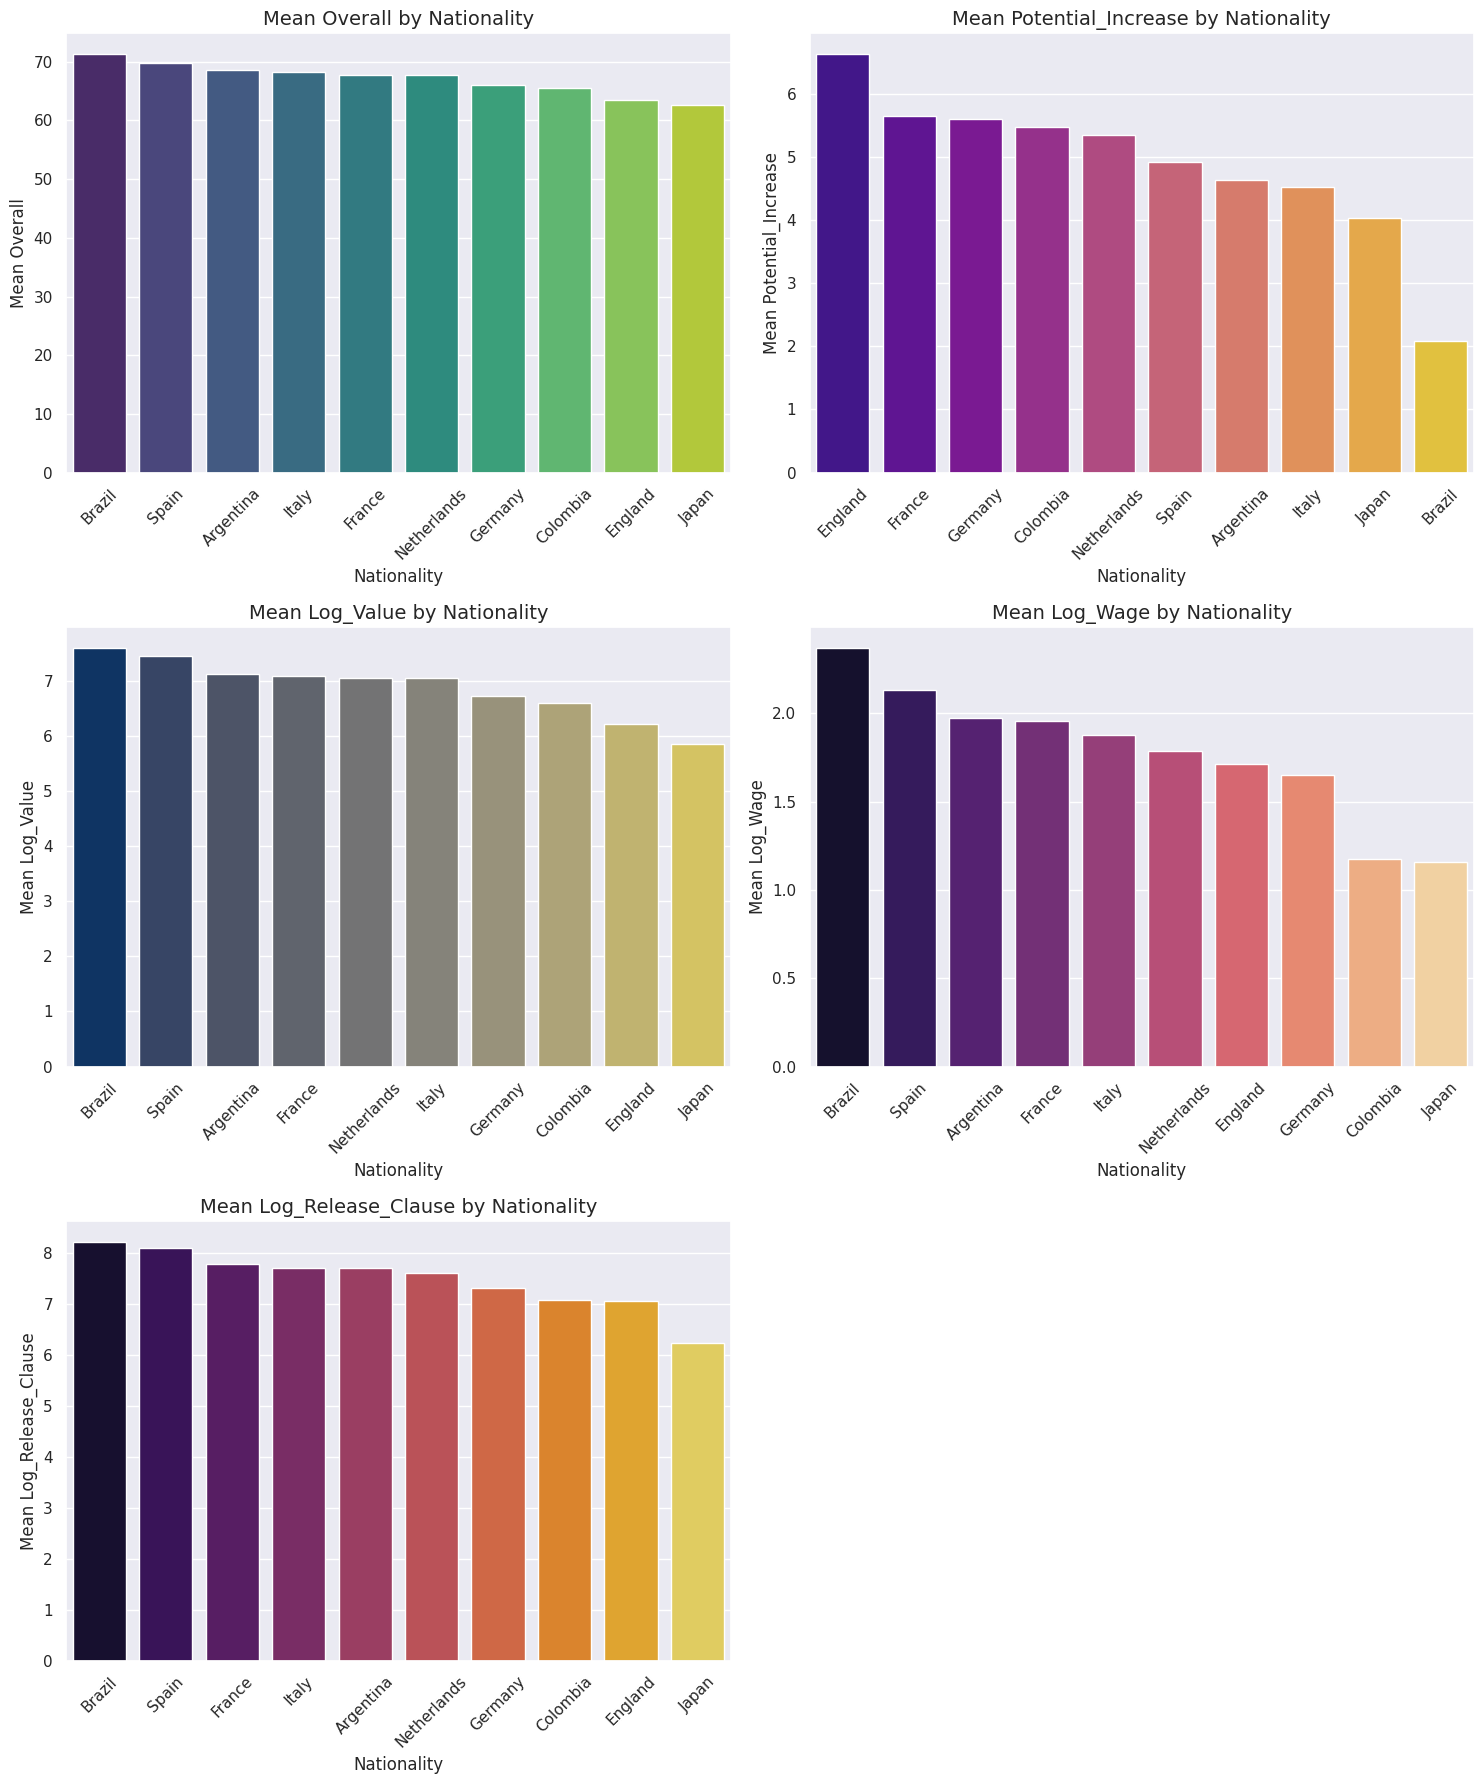

In [388]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

metrics_to_plot = ['Overall', 'Potential_Increase', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
colors = ['viridis', 'plasma', 'cividis', 'magma', 'inferno']

for i, metric in enumerate(metrics_to_plot):
    plot_data = nations.groupby('Nationality', observed=False)[metric].mean().sort_values(ascending=False).reset_index()
    sns.barplot(x='Nationality', y=metric, data=plot_data, ax=axes[i], hue='Nationality', palette=colors[i], legend=False)
    axes[i].set_title(f'Mean {metric} by Nationality', fontsize=14)
    axes[i].set_xlabel('Nationality', fontsize=12)
    axes[i].set_ylabel(f'Mean {metric}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

From the Financial prespective Brazilian players are the top payed players in the world and the top valued players also after them the spanish players but they have very low potential increase rate which means that the Brazilian players aren't consistent at all even if they have the highest overall also

The heighest potential increase players are the English players which means even if they are not the top most payed players but they are consistent and discipline

In [393]:
top_10_clubs=df['Club'].value_counts().head(10).index.to_list()
clubs=df[df['Club'].isin(top_10_clubs)]
display(clubs.head())


,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,Height,Weight,Release Clause,Potential_Increase,YearsInClub,YearsInClub_Category,Log_Value,Log_Wage,Log_Release_Clause,AgeRange
3,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,...,6.333333,168.0,138600.0,2,8,6-10,11.184435,5.564520,11.839355,[25-27]
16,H. Kane,24,England,89,91,Tottenham Hotspur,83500.0,205.0,Right,3.0,...,6.166667,196.0,160700.0,2,9,6-10,11.332614,5.327876,11.987301,[22-24]
31,C. Eriksen,26,Denmark,88,91,Tottenham Hotspur,73500.0,205.0,Right,3.0,...,5.916667,168.0,141500.0,3,6,6-10,11.205054,5.327876,11.860062,[25-27]
33,P. Aubameyang,29,Gabon,88,88,Arsenal,59000.0,265.0,Right,3.0,...,6.166667,176.0,112100.0,0,1,1-5,10.985310,5.583496,11.627156,[28-30]
37,H. Lloris,31,France,88,88,Tottenham Hotspur,36000.0,150.0,Left,4.0,...,6.166667,181.0,66600.0,0,7,6-10,10.491302,5.017280,11.106475,[31-33]


In [394]:
clubs.groupby('Club')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase         \
                              mean median max min               mean median   
Club                                                                          
AS Monaco                72.939394   75.0  84  62           8.000000    8.0   
Arsenal                  75.181818   78.0  88  58           6.212121    3.0   
Borussia Dortmund        75.333333   79.0  86  57           7.060606    5.0   
Cardiff City             68.181818   70.0  76  52           3.696970    2.0   
Manchester United        77.242424   79.0  91  63           5.424242    2.0   
RC Celta                 72.454545   75.0  84  61           6.212121    6.0   
TSG 1899 Hoffenheim      73.030303   76.0  83  58           6.151515    4.0   
Tottenham Hotspur        76.696970   80.0  89  61           5.363636    3.0   
Valencia CF              74.696970   77.0  85  61           6.757576    5.0   
Wolverhampton Wanderers  68.818182   72.0  83  54           8.757576    6.0   

                                Log_Value                                 \
                        max min      mean    median        max       min   
Club                                                                       
AS Monaco                22   0  8.336939  8.779711  10.126671  6.111467   
Arsenal                  21   0  8.615249  9.105091  10.985310  5.484797   
Borussia Dortmund        20   0  8.817888  9.433564  10.680539  5.398163   
Cardiff City             16   0  7.186434  7.824446   9.259226  4.394449   
Manchester United        20   0  9.071075  9.392745  11.184435  6.516193   
RC Celta                 18   0  8.233201  8.853808  10.308986  6.111467   
TSG 1899 Hoffenheim      19   0  8.369540  8.922792  10.165890  5.398163   
Tottenham Hotspur        19   0  9.018267  9.581973  11.332614  6.111467   
Valencia CF              20   0  8.713238  9.259226  10.518700  6.165418   
Wolverhampton Wanderers  23   0  7.566659  7.550135   9.928229  4.795791   

                         Log_Wage                                \
                             mean    median       max       min   
Club                                                              
AS Monaco                3.311018  3.663562  4.753590  1.098612   
Arsenal                  3.937506  4.406719  5.583496  1.609438   
Borussia Dortmund        3.333217  3.784190  4.615121  1.386294   
Cardiff City             2.944076  3.135494  4.025352  1.098612   
Manchester United        4.270042  4.709530  5.564520  2.197225   
RC Celta                 2.571987  2.833213  3.828641  1.098612   
TSG 1899 Hoffenheim      2.944804  3.332205  4.007333  1.098612   
Tottenham Hotspur        3.985876  4.382027  5.327876  1.386294   
Valencia CF              2.962121  3.401197  4.663439  0.693147   
Wolverhampton Wanderers  2.939725  2.833213  4.454347  1.098612   

                        Log_Release_Clause                                  
                                      mean     median        max       min  
Club                                                                        
AS Monaco                         9.100410   9.457279  10.768506  7.003974  
Arsenal                           9.359591   9.787010  11.627156  6.408529  
Borussia Dortmund                 9.406262   9.966509  11.211834  6.240276  
Cardiff City                      7.846778   8.430777   9.655090  5.176150  
Manchester United                 9.784123  10.047631  11.839355  7.244942  
RC Celta                          8.955971   9.148571  11.050906  7.090910  
TSG 1899 Hoffenheim               8.993620   9.457279  10.740757  5.926926  
Tottenham Hotspur                 9.723471  10.196194  11.987301  6.828712  
Valencia CF                       9.472377   9.883336  11.260623  7.090910  
Wolverhampton Wanderers           8.195489   8.268988  10.671301  5.796058

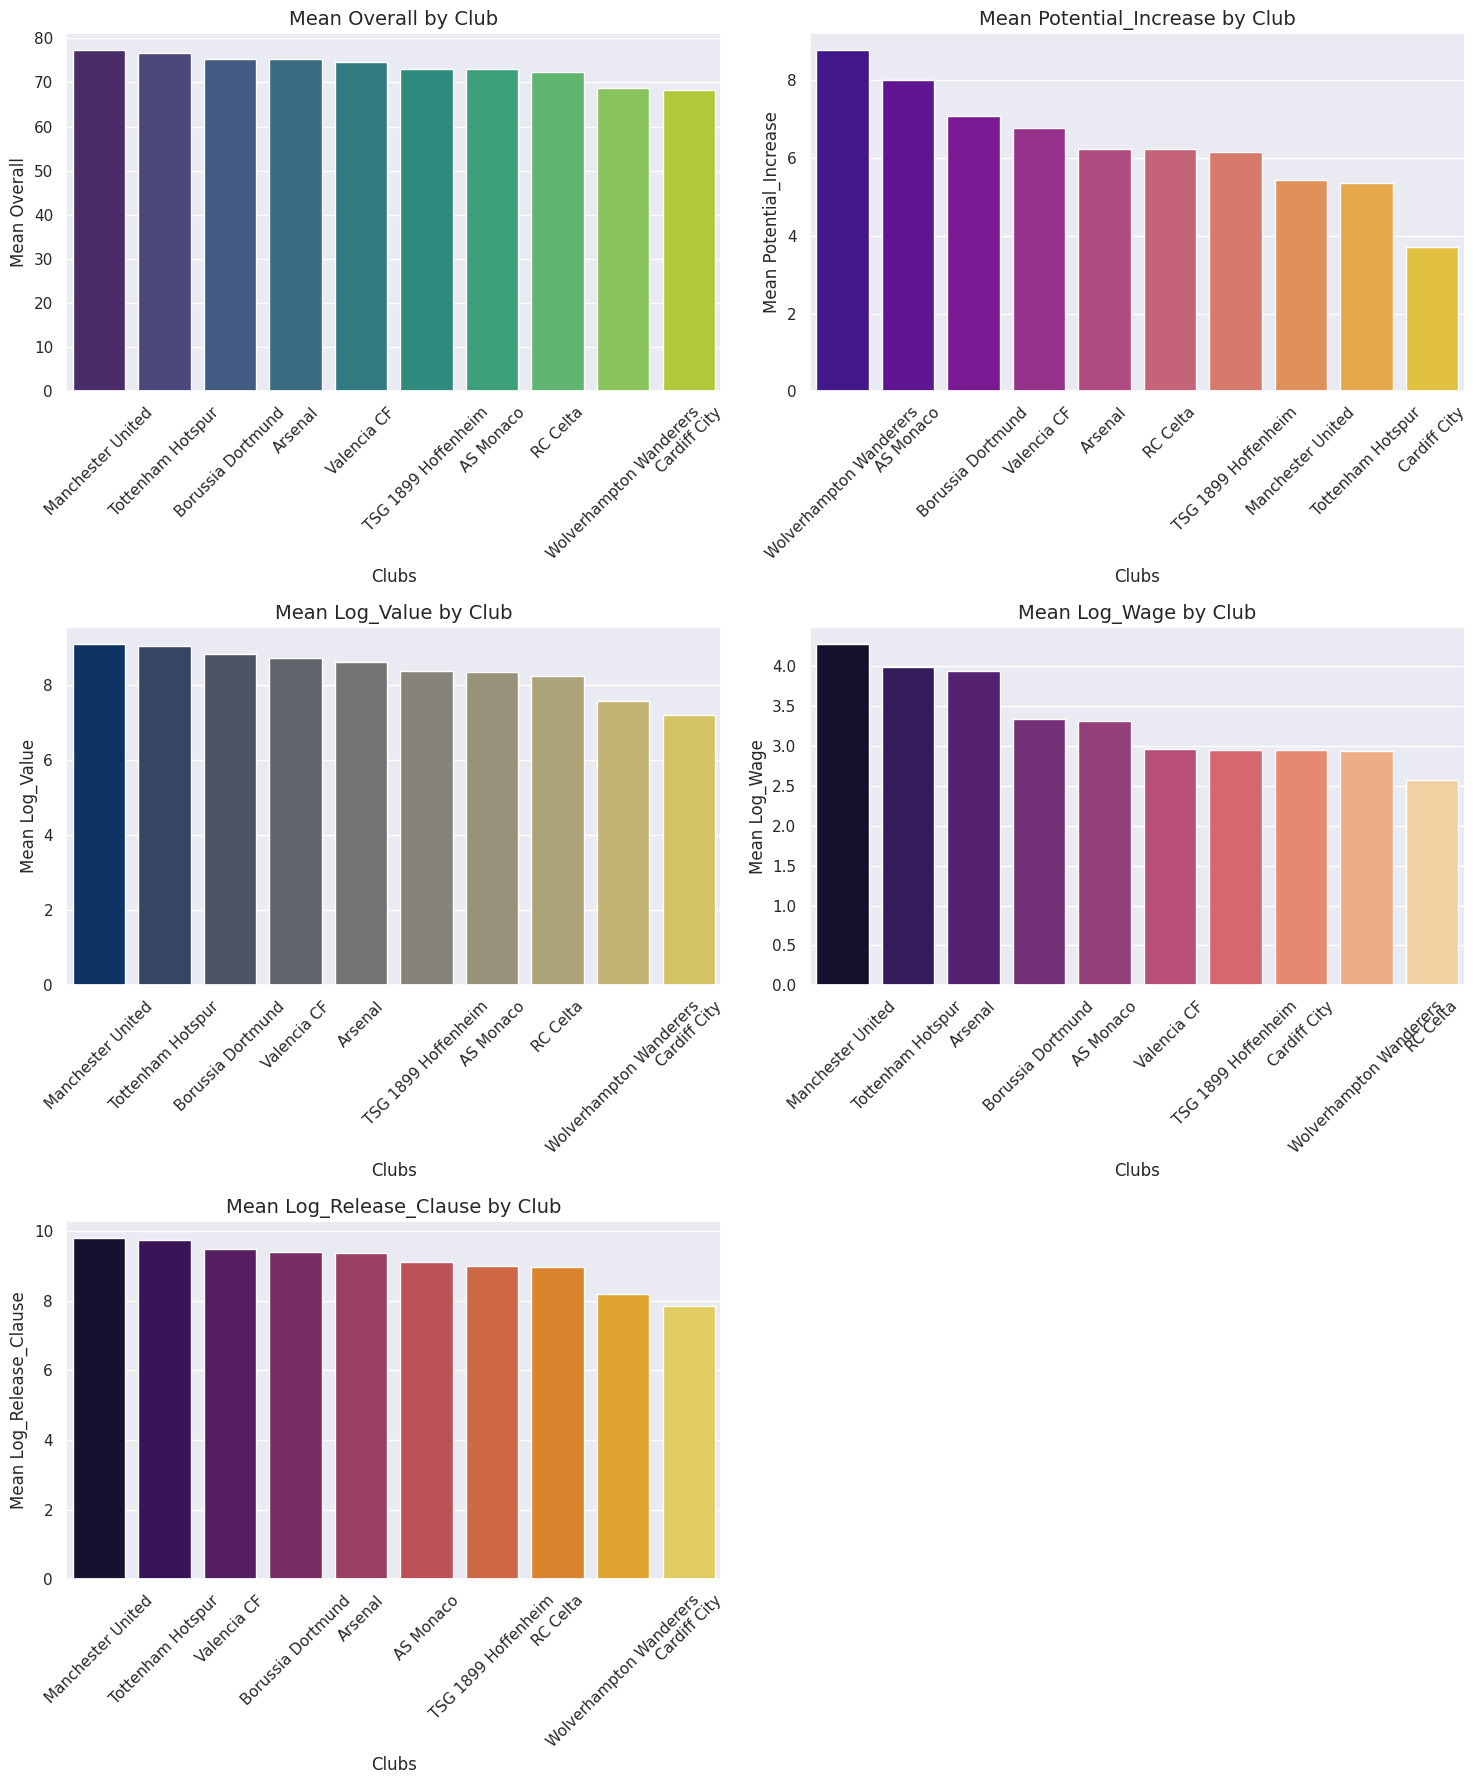

In [395]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

metrics_to_plot = ['Overall', 'Potential_Increase', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
colors = ['viridis', 'plasma', 'cividis', 'magma', 'inferno']

for i, metric in enumerate(metrics_to_plot):
    plot_data = clubs.groupby('Club', observed=False)[metric].mean().sort_values(ascending=False).reset_index()
    sns.barplot(x='Club', y=metric, data=plot_data, ax=axes[i], hue='Club', palette=colors[i], legend=False)
    axes[i].set_title(f'Mean {metric} by Club', fontsize=14)
    axes[i].set_xlabel('Clubs', fontsize=12)
    axes[i].set_ylabel(f'Mean {metric}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Top-tier clubs like Manchester United, Tottenham Hotspur, and Arsenal consistently feature players with high average 'Overall' ratings, market 'Value', and 'Wage'. This indicates that these clubs attract and retain top talent. However, some other clubs like AS Monaco and Wolverhampton Wanderers, while not always leading in current overall ratings or financial metrics, show a notable average 'Potential_Increase', suggesting they might be strong in developing promising young players or acquiring players with significant growth potential.



In [397]:
df.groupby('Preferred Foot')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase                 \
                     mean median max min               mean median max min   
Preferred Foot                                                               
Left            66.790575   67.0  94  47           4.971387    3.0  26   0   
Right           66.072883   66.0  94  46           5.133256    4.0  26   0   

               Log_Value                                 Log_Wage            \
                    mean    median        max       min      mean    median   
Preferred Foot                                                                
Left            6.831317  6.621406  11.612780  2.397895  1.768415  1.609438   
Right           6.683540  6.516193  11.682677  2.397895  1.683844  1.386294   

                                   Log_Release_Clause                       \
                     max       min               mean    median        max   
Preferred Foot                                                               
Left            6.338594  0.693147           7.463633  7.313887  12.330505   
Right           6.122493  0.693147           7.302978  7.170888  12.337544   

                          
                     min  
Preferred Foot            
Left            2.639057  
Right           2.639057

In essence, while the differences are not dramatic, this analysis hints that left-footed players might be marginally more proficient and command higher financial figures, whereas right-footed players, on average, might possess a bit more untapped potential.

In [398]:
df.groupby('International Reputation')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase         \
                               mean median max min               mean median   
International Reputation                                                       
1.0                       65.168916   66.0  85  46           5.493435    4.0   
2.0                       75.584739   76.0  86  54           1.102008    0.0   
3.0                       81.381107   81.0  90  68           1.068404    0.0   
4.0                       86.215686   86.0  91  80           0.294118    0.0   
5.0                       90.833333   91.5  94  85           0.166667    0.0   

                                  Log_Value                                  \
                         max min       mean     median        max       min   
International Reputation                                                      
1.0                       26   0   6.516256   6.439350  10.747229  2.397895   
2.0                       12   0   8.471500   8.779711  11.018646  3.044522   
3.0                       11   0   9.635607   9.770013  11.396403  5.351858   
4.0                        4   0  10.269360  10.532123  11.532738  7.313887   
5.0                        1   0  10.988179  11.270684  11.682677  9.546884   

                          Log_Wage                                \
                              mean    median       max       min   
International Reputation                                           
1.0                       1.538052  1.386294  4.948760  0.693147   
2.0                       3.136486  3.258097  5.327876  0.693147   
3.0                       4.076989  4.276666  5.831882  0.693147   
4.0                       4.878606  5.111988  6.042633  2.397895   
5.0                       5.298092  5.839838  6.338594  2.772589   

                         Log_Release_Clause                                  
                                       mean     median        max       min  
International Reputation                                                     
1.0                                7.148915   7.003974  11.389639  2.639057  
2.0                                8.980476   9.230241  11.736877  3.258097  
3.0                               10.197403  10.335302  12.020351  5.723585  
4.0                               10.761761  11.106475  12.187914  8.006701  
5.0                               11.571145  11.880183  12.337544  9.952325

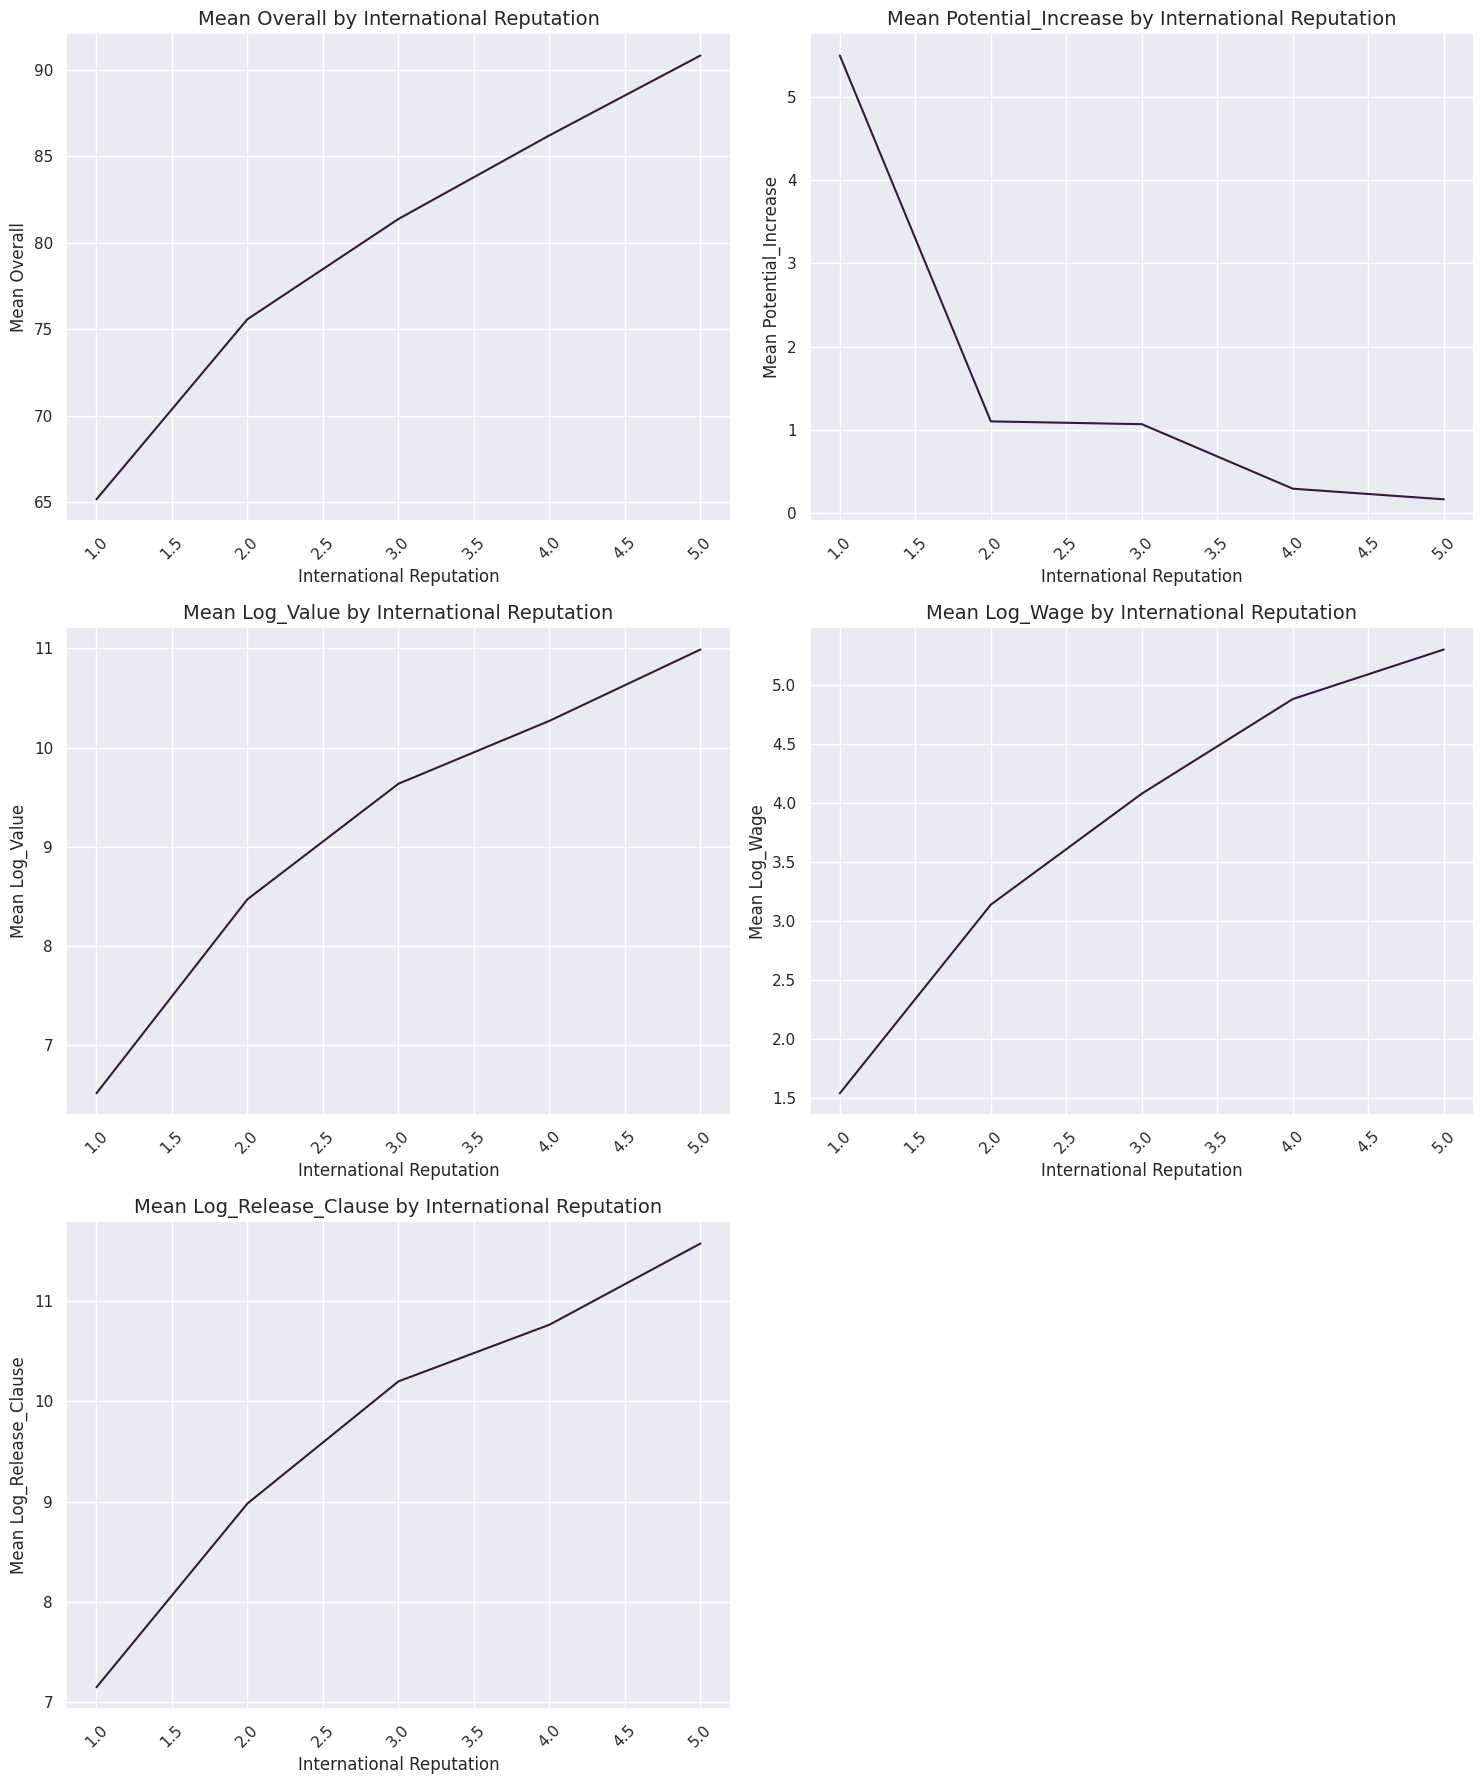

In [400]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

metrics_to_plot = ['Overall', 'Potential_Increase', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
colors = ['viridis', 'plasma', 'cividis', 'magma', 'inferno']

for i, metric in enumerate(metrics_to_plot):
    plot_data = df.groupby('International Reputation', observed=False)[metric].mean().sort_values(ascending=False).reset_index()
    sns.lineplot(x='International Reputation', y=metric, data=plot_data, ax=axes[i])
    axes[i].set_title(f'Mean {metric} by International Reputation', fontsize=14)
    axes[i].set_xlabel('International Reputation', fontsize=12)
    axes[i].set_ylabel(f'Mean {metric}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The data reveals a strong positive correlation between International Reputation and a player’s current financial standing (Value, Wage, and Release Clause). However, there is a notable trade-off regarding development: as a player’s reputation increases, their Potential Growth (the gap between their Current Rating and Potential Rating) tends to decrease. This suggests that 'top-tier' famous players have already reached their peak, whereas less famous players possess the highest margin for improvement

In [402]:
df.groupby('Skill Moves')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase                 \
                  mean median max min               mean median max min   
Skill Moves                                                               
1.0          64.583208   64.0  91  47           5.241830    4.0  25   0   
2.0          63.542718   63.0  90  46           5.934826    5.0  26   0   
3.0          68.865603   69.0  91  48           4.227984    3.0  24   0   
4.0          75.301866   76.0  94  56           3.358946    1.0  21   0   
5.0          79.860000   80.5  94  66           2.400000    1.0  15   0   

            Log_Value                                 Log_Wage            \
                 mean    median        max       min      mean    median   
Skill Moves                                                                
1.0          6.072531  5.929589  11.184435  2.397895  1.431243  1.098612   
2.0          6.168115  6.111467  11.050906  2.397895  1.372047  1.098612   
3.0          7.315947  7.090910  11.332614  3.044522  2.016755  1.945910   
4.0          8.783695  8.987322  11.612780  4.948760  3.018105  3.091042   
5.0          9.569577  9.755520  11.682677  6.398595  3.683742  3.688879   

                                Log_Release_Clause                        \
                  max       min               mean     median        max   
Skill Moves                                                                
1.0          5.564520  0.693147           6.687357   6.499787  11.881042   
2.0          5.655992  0.693147           6.815395   6.660575  11.747215   
3.0          6.122493  0.693147           7.922619   7.863651  12.007628   
4.0          6.338594  0.693147           9.309562   9.495594  12.330505   
5.0          6.006353  0.693147          10.113356  10.390892  12.337544   

                       
                  min  
Skill Moves            
1.0          2.639057  
2.0          2.639057  
3.0          3.258097  
4.0          5.613128  
5.0          6.803505

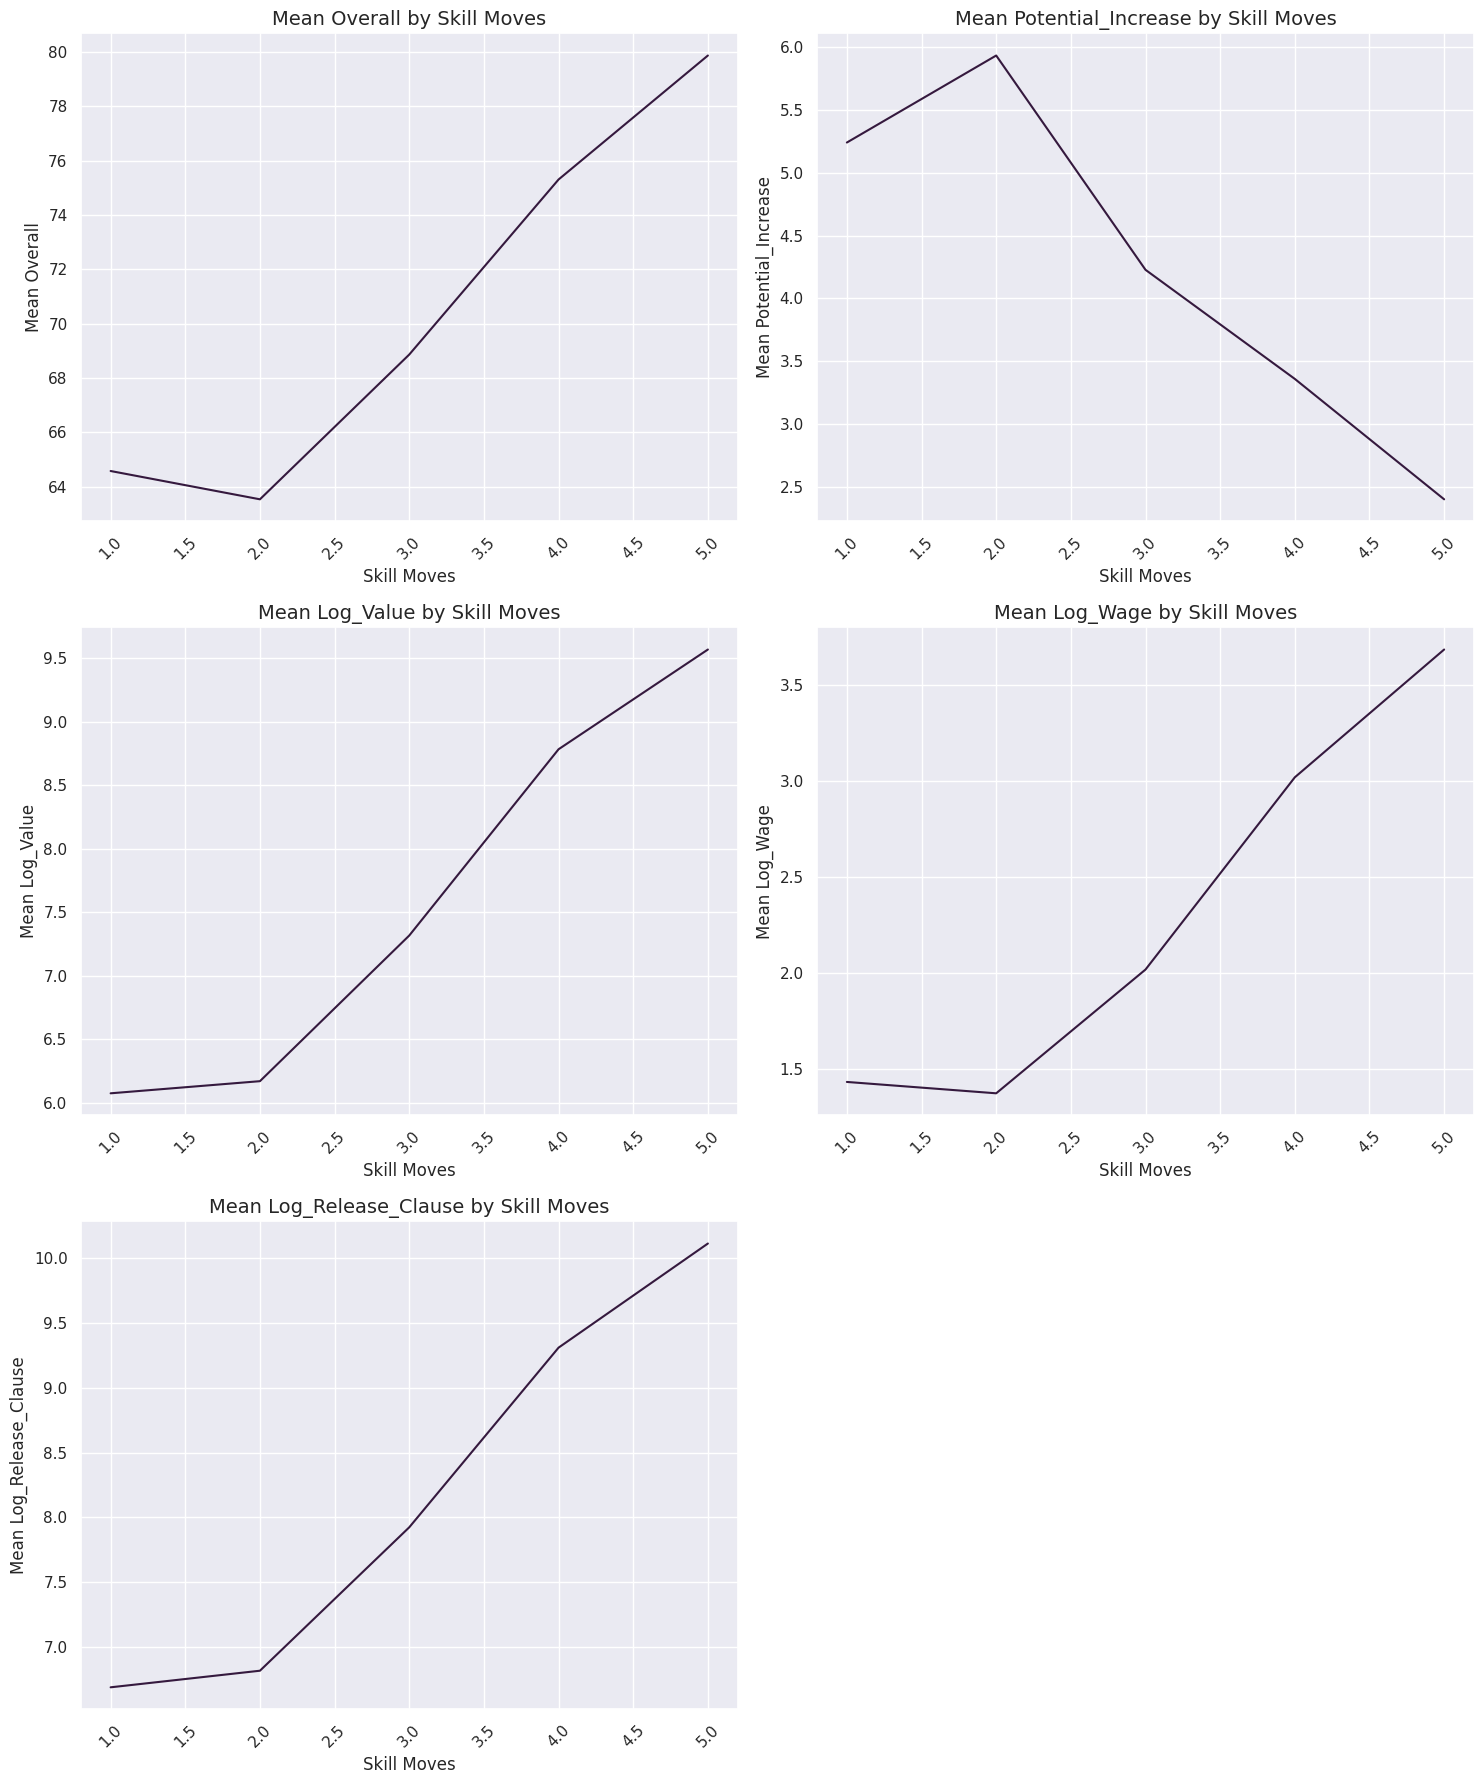

In [403]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

metrics_to_plot = ['Overall', 'Potential_Increase', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
colors = ['viridis', 'plasma', 'cividis', 'magma', 'inferno']

for i, metric in enumerate(metrics_to_plot):
    plot_data = df.groupby('Skill Moves', observed=False)[metric].mean().sort_values(ascending=False).reset_index()
    sns.lineplot(x='Skill Moves', y=metric, data=plot_data, ax=axes[i])
    axes[i].set_title(f'Mean {metric} by Skill Moves', fontsize=14)
    axes[i].set_xlabel('Skill Moves', fontsize=12)
    axes[i].set_ylabel(f'Mean {metric}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Similar to International Reputation, Skill Move ratings show a strong positive correlation with a player's financial valuation, yet an inverse relationship with their future growth. Players with high Skill Move ratings (4 or 5 stars) typically command the highest market value and wages, reflecting their status as 'elite entertainers' and finished products. However, these 'highly skilled' players show a significantly lower Potential Gap (Potential minus Overall), as their technical abilities are already at or near their maximum ceiling. Conversely, players with lower skill ratings often possess the highest margin for growth, representing 'raw' talents that have yet to reach their technical peak.

In [407]:
df.groupby('Position')[['Overall','Potential_Increase','Log_Value','Log_Wage','Log_Release_Clause']].agg(['mean','median','max','min'])

Overall                Potential_Increase                 \
               mean median max min               mean median max min   
Position                                                               
CAM       66.867865   67.0  89  48           5.763214    4.0  22   0   
CB        64.993718   65.0  90  48           5.910337    5.0  24   0   
CDM       66.313034   66.0  89  47           5.216880    4.0  23   0   
CF        65.824324   65.5  82  50           6.918919    5.5  21   0   
CM        63.697168   64.0  86  46           7.206245    7.0  26   0   
GK        64.583208   64.0  91  47           5.241830    4.0  25   0   
LAM       71.857143   71.0  88  66           0.666667    0.0   9   0   
LB        65.848926   66.0  88  47           4.689417    3.0  22   0   
LCB       69.218898   69.0  89  54           3.105512    2.0  17   0   
LCM       69.334190   69.0  90  48           3.478149    2.0  19   0   
LDM       69.100418   70.0  89  48           3.251046    1.0  22   0   
LF        73.866667   71.0  91  62           2.733333    0.0  14   0   
LM        66.675875   67.0  88  48           5.078269    3.0  24   0   
LS        70.077670   70.0  89  56           2.757282    1.0  21   0   
LW        66.639037   66.0  92  50           6.532086    6.0  21   0   
LWB       66.512821   66.0  80  50           4.166667    2.5  20   0   
RAM       72.285714   72.0  84  64           0.571429    0.0   6   0   
RB        66.032334   66.0  86  47           4.448738    3.0  24   0   
RCB       69.315951   69.0  91  54           2.937117    1.0  18   0   
RCM       69.105943   69.0  91  52           3.426357    1.0  18   0   
RDM       69.739837   70.0  87  54           2.731707    1.0  19   0   
RF        73.250000   71.0  94  65           2.187500    0.0  11   0   
RM        66.473070   66.0  88  48           5.056553    3.0  22   0   
RS        69.537313   69.0  91  51           2.900498    1.0  17   0   
RW        66.835616   67.0  86  47           6.471233    6.0  23   0   
RWB       64.655172   64.0  80  48           5.298851    4.0  19   0   
ST        65.512676   66.0  94  47           5.605634    4.0  26   0   

         Log_Value                                 Log_Wage            \
              mean    median        max       min      mean    median   
Position                                                                
CAM       7.016873  6.830874  11.264477  3.044522  1.745443  1.386294   
CB        6.402282  6.265301  10.950824  2.397895  1.552700  1.386294   
CDM       6.649355  6.516193  10.993748  3.044522  1.690887  1.386294   
CF        6.897180  6.654153  10.257694  3.931826  1.719307  1.386294   
CM        6.421735  6.265301  10.829748  2.397895  1.540999  1.098612   
GK        6.072531  5.929589  11.184435  2.397895  1.431243  1.098612   
LAM       7.714754  7.438972  11.149096  6.265301  2.498247  2.397895   
LB        6.532698  6.356108  10.668979  3.044522  1.648354  1.386294   
LCB       7.124219  6.908755  10.839601  4.110874  1.918539  1.791759   
LCM       7.386096  7.090910  11.245059  3.931826  2.020726  1.791759   
LDM       7.196653  7.003974  11.050906  3.713572  1.881909  1.791759   
LF        8.306765  7.741099  11.440366  5.707110  2.492353  2.302585   
LM        6.961007  6.775366  10.985310  3.433987  1.751891  1.609438   
LS        7.560627  7.378384  11.002117  4.875197  2.167998  1.945910   
LW        7.021353  6.857514  11.682677  3.931826  1.828849  1.609438   
LWB       6.717641  6.356108   9.581973  4.110874  1.704999  1.386294   
RAM       7.943432  7.824446  10.389026  6.265301  2.506116  2.564949   
RB        6.557830  6.398595  10.463132  3.433987  1.655539  1.386294   
RCB       7.156745  6.883463  10.839601  3.433987  1.935970  1.609438   
RCM       7.319128  7.003974  11.532738  4.262680  2.006237  1.609438   
RDM       7.301304  7.090910  11.066654  4.394449  1.989088  1.945910   
RF        8.055738  8.070730  11.612780  5.398163  2.620194  2.524928   
RM        6.925239  6.7165

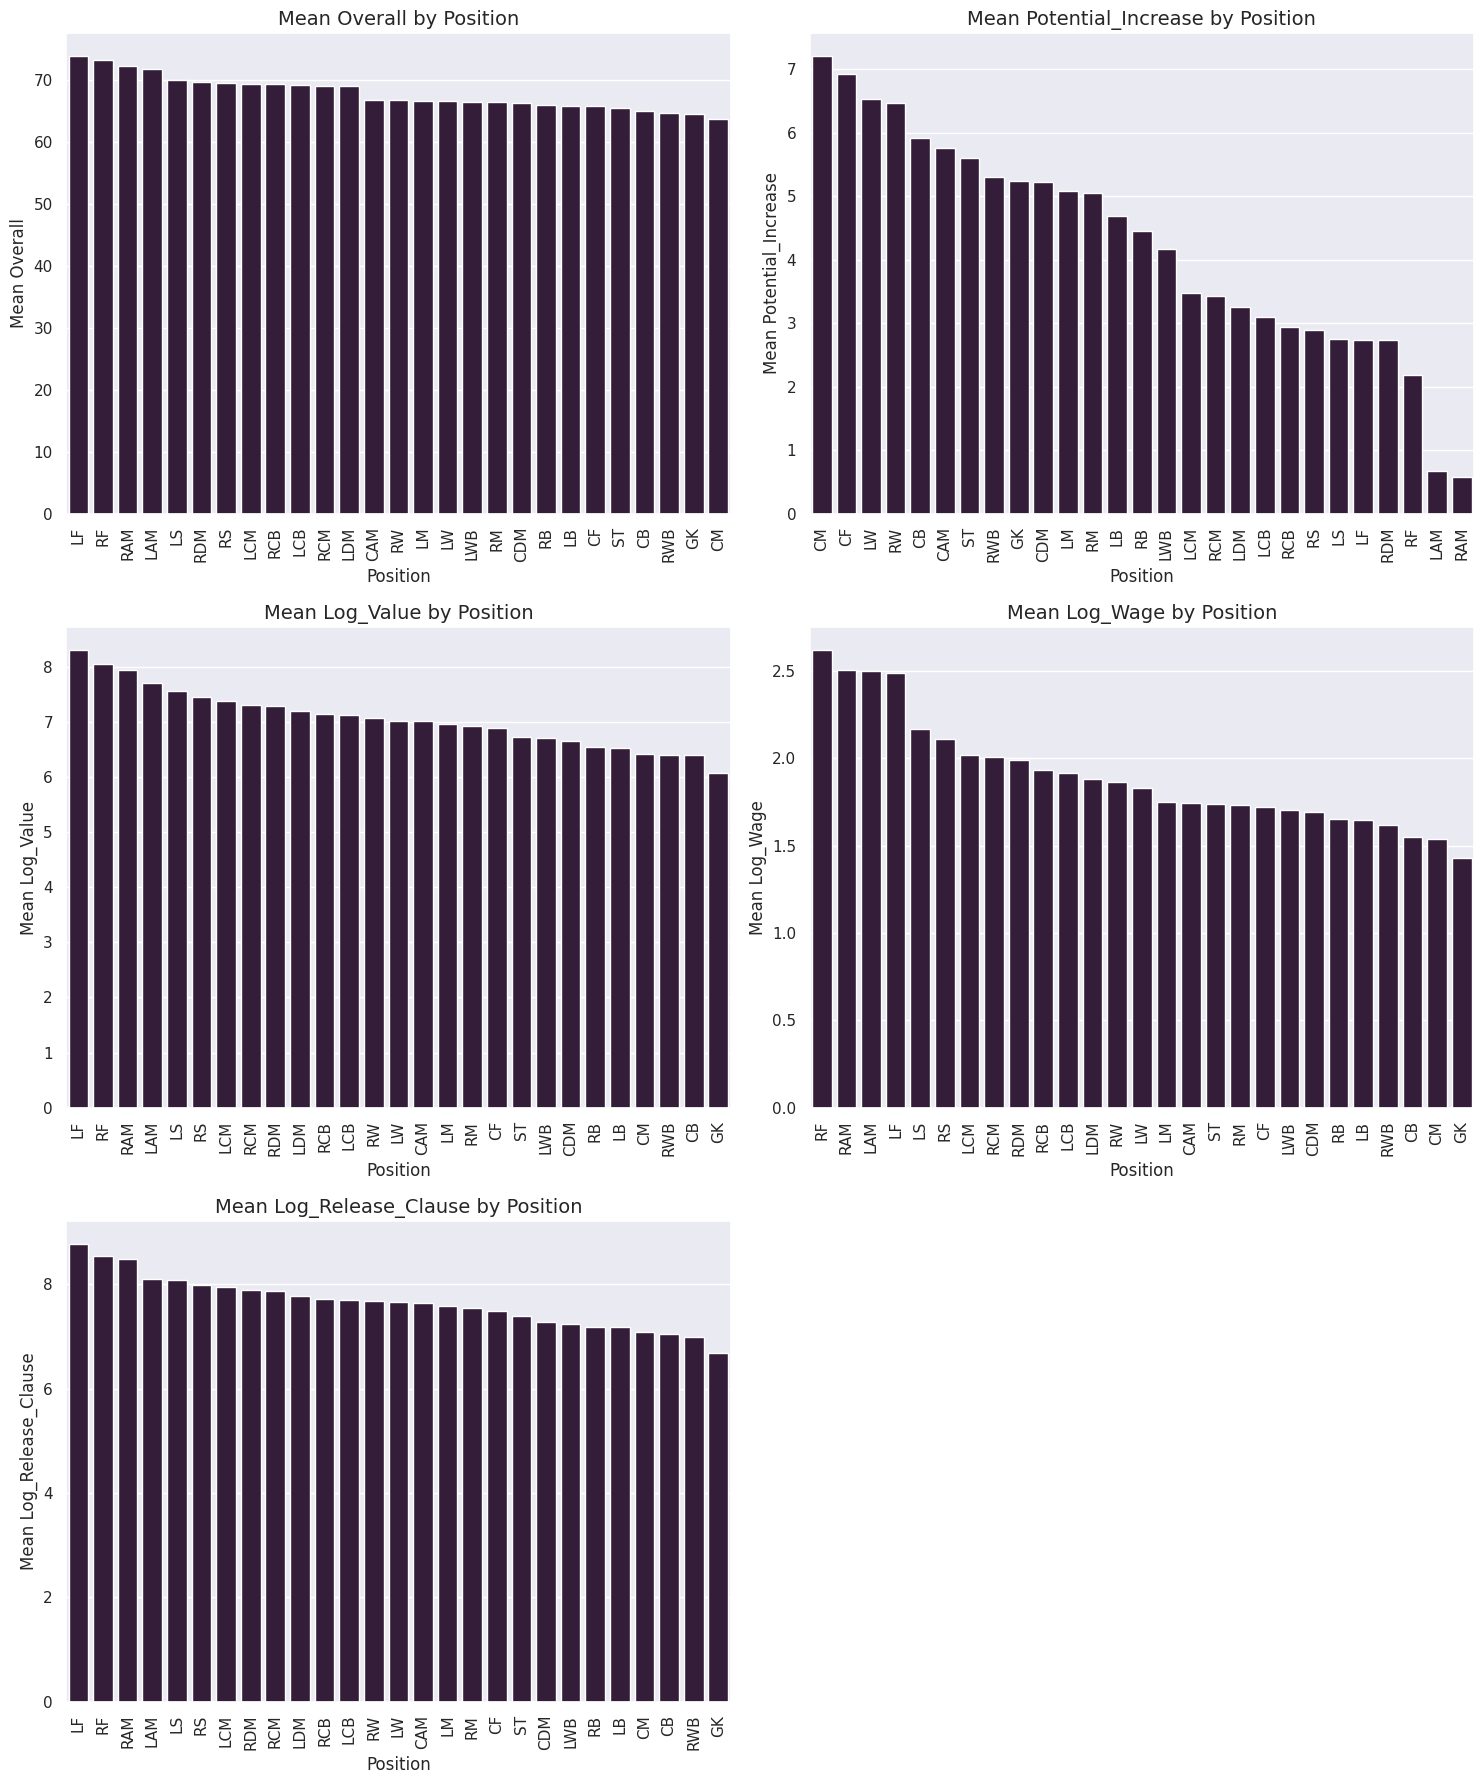

In [408]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

metrics_to_plot = ['Overall', 'Potential_Increase', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
colors = ['viridis', 'plasma', 'cividis', 'magma', 'inferno']

for i, metric in enumerate(metrics_to_plot):
    plot_data = df.groupby('Position', observed=False)[metric].mean().sort_values(ascending=False).reset_index()
    sns.barplot(x='Position', y=metric, data=plot_data, ax=axes[i])
    axes[i].set_title(f'Mean {metric} by Position', fontsize=14)
    axes[i].set_xlabel('Position', fontsize=12)
    axes[i].set_ylabel(f'Mean {metric}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=90)
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Players in highly offensive and specialized roles (like LF, RF, LAM, RAM) generally have the highest 'Overall' ratings and command the highest market value, wages, and release clauses. However, these 'top-tier' offensive positions often show very low 'Potential_Increase', indicating they are largely finished products. Conversely, positions like CM, CF, LW, and RW, while having slightly lower current average 'Overall' ratings, exhibit higher 'Potential_Increase', suggesting they have more room for future development.

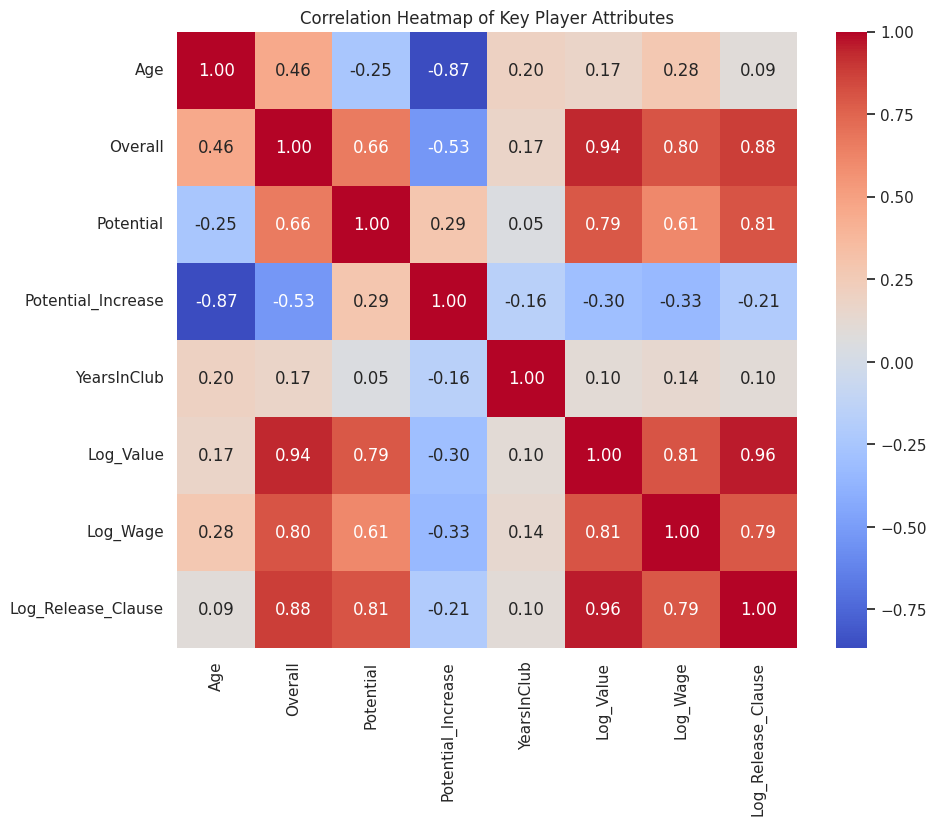

In [412]:
selected_features = ['Age', 'Overall', 'Potential', 'Potential_Increase', 'YearsInClub', 'Log_Value', 'Log_Wage', 'Log_Release_Clause']
corr_matrix = df[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Player Attributes')
plt.show()

## Comprehensive EDA Summary: FIFA Player Dataset Analysis

This notebook presents a thorough Exploratory Data Analysis (EDA) of a FIFA player dataset, covering data cleaning, feature engineering, univariate distributions, and multivariate relationships to uncover key insights into player attributes, valuation, and career dynamics.

### Key Findings:

1.  **Data Quality & Preprocessing:**
    *   Initial inspection revealed missing values in `Club`, `Value`, `International Reputation`, `Skill Moves`, and `Contract Valid Until`, which were addressed by dropping affected rows.
    *   The `ID` column, being non-analytical, was removed.
    *   `Value`, `Wage`, and `Release Clause` were highly right-skewed; a `log1p` transformation effectively normalized their distributions, making them suitable for statistical analysis and outlier detection.
    *   Outlier analysis for various numerical features (Age, Overall, Height, Weight, etc.) showed minimal impact on central tendencies post-removal, indicating robust distributions for the majority of players.

2.  **Feature Engineering & Age Dynamics:**
    *   **`Potential_Increase`**: Calculated as `Potential - Overall`, this metric quantifies future growth potential. Young players (16-24) exhibit the highest `Potential_Increase`, which sharply declines after age 28-30, suggesting older players have largely reached their peak.
    *   **`YearsInClub`**: Derived from `Joined` year, it shows a positive correlation with `AgeRange`. The distribution reveals that while younger players have short tenures, older players show a wider spread of tenure, including long-serving veterans.
    *   **`AgeRange`**: Categorizing players by age revealed that `Overall` ratings and financial metrics (`Log_Value`, `Log_Wage`, `Log_Release_Clause`) generally increase with age, peaking in the 25-33 age bracket, then gradually declining. This highlights a 'prime-age premium' for player market worth.

3.  **Player Attributes & Performance:**
    *   **Preferred Foot**: A significant majority (76.8%) of players are right-footed. Left-footed players, on average, showed slightly higher `Overall` ratings and financial metrics, while right-footed players had marginally higher `Potential_Increase`.
    *   **International Reputation & Skill Moves**: Both metrics strongly correlate with `Overall` rating and financial value. Higher reputation/skill players command premium financial terms but show lower `Potential_Increase`, indicating they are often 'finished products'. Conversely, lower-rated players in these categories tend to have more room for development.
    *   **Position**: Highly offensive and specialized roles (e.g., LF, RF, LAM) boast the highest average `Overall` ratings and financial values but lowest `Potential_Increase`. Central midfielders (CM) and wide attackers (LW, RW) often show higher `Potential_Increase`, suggesting developmental roles.

4.  **Nationality & Club Insights:**
    *   **Nationality**: Brazilian and Spanish players, on average, command the highest `Log_Value`, `Log_Wage`, and `Log_Release_Clause`, often with high `Overall` ratings. English players, however, exhibit the highest `Potential_Increase`, suggesting a strong pipeline of developing talent.
    *   **Clubs**: Top-tier clubs like Manchester United, Tottenham Hotspur, and Arsenal house players with high average `Overall` ratings and financial metrics. Other clubs, such as AS Monaco and Wolverhampton Wanderers, show high `Potential_Increase` in their squads, pointing to a focus on talent development.

5.  **Financial Dynamics:**
    *   A strong positive correlation exists between `Overall` rating and `Log_Value`, `Log_Wage`, and `Log_Release_Clause`, reinforcing that higher-skilled players are more financially valuable.
    *   Identification of **'Bargain Players'** (high `Potential_Increase` and low `Log_Value`) highlights opportunities for scouting promising talent at a lower cost, often found among younger, lower-rated players.

### Conclusion:
This EDA provides a robust foundation for understanding player dynamics in football. It reveals that while current skill dictates market value and wages, future potential is concentrated in younger players. The analysis across age, nationality, club, and position offers actionable insights for scouting, player development, and strategic team building.